# Análisis Inferencial


* Luisa Merlo García | A01067715
* Edgar Osvaldo Navarro | A01644488
* Ariana Guadalupe Rosales Villalobos | A01644773


## Ejercicio 1 (60 puntos)

La base de datos Palmer PenguinsDescargar Palmer Penguins contiene información sobre 344 pingüinos observados en el archipiélago Palmer, en la Antártida. Incluye ejemplares de tres especies distintas y registra tanto características físicas como información sobre el lugar y el año de observación, por lo que permite comparar grupos y estudiar relaciones entre variables.

Para esta base de datos, analiza lo siguiente:

### A. Masa corporal

Analiza la variable masa corporal (body_mass_g) y realiza lo siguiente:


In [94]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols

penguins = pd.read_csv("penguins.txt")

penguins.groupby("species")["body_mass_g"].count()

species
Adelie       151
Chinstrap     68
Gentoo       123
Name: body_mass_g, dtype: int64

In [95]:
# Construye un intervalo de confianza del 95 % para la  masa corporal media de todos los pingüinos.

body_mass = penguins["body_mass_g"].dropna()

x = body_mass
cl = 0.95
alpha = 1 - cl

# Calcular std y media poblacional
sample_mean = np.mean(x)
sample_std_dev = np.std(x, ddof=1)
sample_size = len(x)

# Calcular el valor critico de distribucion t
t_score = stats.t.ppf(1 - alpha/2, df=sample_size - 1)

# Calcular el margen de error y el intervalo de confianza
margin_of_error = t_score * sample_std_dev / np.sqrt(sample_size)

confidence_interval = (
    sample_mean - margin_of_error,
    sample_mean + margin_of_error
)

print("Sample size =", sample_size)
print("Sample mean =", sample_mean)
print("Desviación estándar de la muestra =", sample_std_dev)
print("t-score =", t_score)
print("Margen de error =", margin_of_error)
print("95% Intervalo de confianza =", confidence_interval)

Sample size = 342
Sample mean = 4201.754385964912
Desviación estándar de la muestra = 801.9545356980955
t-score = 1.9669451293272178
Margen de error = 85.29605394086734
95% Intervalo de confianza = (np.float64(4116.4583320240445), np.float64(4287.05043990578))


Con un intervalo de confiaza del 95% podemos estimar que la poblacional de la masa corporal de los pinguinos se encuentra entre 4116.46 gr y 4287.05gr. La media muestral de 342 pinguinos observados fue de 4201.75 gr.

In [96]:
# 2. Construye intervalos de confianza del 95 % para la masa corporal media de cada especie.
species_list = penguins["species"].unique()

cl = 0.95
alpha = 1 - cl

for species in species_list:
    
    # Seleccionar los valores de masa corporal de las especies
    x = penguins.loc[
        penguins["species"] == species,
        "body_mass_g"
    ].dropna()

    # Estadísticas de la muestra
    sample_mean = np.mean(x)
    sample_std_dev = np.std(x, ddof=1)
    sample_size = len(x)

    # Calcular el valor crítico de la distribución t
    t_score = stats.t.ppf(
        1 - alpha/2,
        df=sample_size - 1
    )

    # Margen de error
    margin_of_error = (
        t_score
        * sample_std_dev
        / np.sqrt(sample_size)
    )

    # Intervalo de confianza
    confidence_interval = (
        sample_mean - margin_of_error,
        sample_mean + margin_of_error
    )

    print(species)
    print("Sample size =", sample_size)
    print("Sample mean =", sample_mean)
    print("95% Intervalo de confianza =", confidence_interval)
    print()

Adelie
Sample size = 151
Sample mean = 3700.662251655629
95% Intervalo de confianza = (np.float64(3626.926242277889), np.float64(3774.398261033369))

Gentoo
Sample size = 123
Sample mean = 5076.016260162602
95% Intervalo de confianza = (np.float64(4986.034279556633), np.float64(5165.99824076857))

Chinstrap
Sample size = 68
Sample mean = 3733.0882352941176
95% Intervalo de confianza = (np.float64(3640.0593266448386), np.float64(3826.1171439433965))



Con un nivel de confianza del 95%, la masa corporal media de los pinguinos Adelie se estima entre 3626.93 g y 3774.40 g, la de Gentoo entre 4986.03 g y 5166.00 g, y la de Chinstrap entre 3640.06 g y 3826.12 g. Los pingunos Gentoo presentan una masa corporal media considerablemente mayor que Adelie y Chinstrap.

In [97]:
# 3. Construye un intervalo de confianza del 95 % para la diferencia de masa corporal media entre machos y hembras.


male = penguins.loc[
    penguins["sex"] == "male",
    "body_mass_g"
].dropna()

female = penguins.loc[
    penguins["sex"] == "female",
    "body_mass_g"
].dropna()

cl = 0.95
alpha = 1 - cl

# Calcular la media y desviación estándar de cada grupo
mean_male = np.mean(male)
std_male = np.std(male, ddof=1)

mean_female = np.mean(female)
std_female = np.std(female, ddof=1)

n_male = len(male)
n_female = len(female)

# Calcular el error estándar de la diferencia de medias
standard_error_diff = np.sqrt(
    std_male**2 / n_male +
    std_female**2 / n_female
)

# grados d confiaza Welch-Satterwhaite
df = (
    std_male**2 / n_male +
    std_female**2 / n_female
)**2 / (
    (std_male**2 / n_male)**2 / (n_male - 1)
    +
    (std_female**2 / n_female)**2 / (n_female - 1)
)

# valor critico t 
t_score = stats.t.ppf(1 - alpha/2, df=df)

# Magen de error
margin_of_error_diff = t_score * standard_error_diff

# Intervalo de confianza para macho y hembra
confidence_interval_diff = (
    mean_male - mean_female - margin_of_error_diff,
    mean_male - mean_female + margin_of_error_diff
)

print("Macho sample size =", n_male)
print("Hembra sample size =", n_female)

print("Promedio macho =", mean_male)
print("Promedio hembra =", mean_female)

print("Diferencia macho - hembra =", mean_male - mean_female)

print("Grados de libertad =", df)

print(
    "95% Intervalo de confianza para macho - hembra =",
    confidence_interval_diff
)

Macho sample size = 168
Hembra sample size = 165
Promedio macho = 4545.684523809524
Promedio hembra = 3862.2727272727275
Diferencia macho - hembra = 683.4117965367964
Grados de libertad = 323.8958810286484
95% Intervalo de confianza para macho - hembra = (np.float64(526.2453315709475), np.float64(840.5782615026452))


La media de la masa coprotal es de 4545.68 g para los machos y 3862.27 g para las hembras, con una diferencia estimada de 683.41 g. Con un nivel de confianza del 95%, la diferencia poblacional entre machos y hembras se encuentra entre 526.25 g y 840.58 g. Los resultados proporcionan evidencia de una diferencia en la masa corporal media entre ambos sexos, siendo mayor en los machos.

In [98]:
# 4. Evalúa el supuesto de normalidad de la masa corporal para cada especie mediante una prueba de normalidad apropiada. Complementa el resultado con una inspección gráfica, por ejemplo mediante histogramas o gráficos Q–Q.


alpha = 0.05

species_list = penguins["species"].unique()

for species in species_list:

    x = penguins.loc[
        penguins["species"] == species,
        "body_mass_g"
    ].dropna()

    shapiro_stat, p_value = stats.shapiro(x)

    print(species)
    print("n =", len(x))
    print("Shapiro-Wilk estadístico =", shapiro_stat)
    print("p-value =", p_value)

    if p_value < alpha:
        print("Rechazar H0: evidencia en contra de la normalidad")
    else:
        print("No se rechaza H0: la normalidad es razonable")

    print()

Adelie
n = 151
Shapiro-Wilk estadístico = 0.9807078505542097
p-value = 0.03239702371600242
Rechazar H0: evidencia en contra de la normalidad

Gentoo
n = 123
Shapiro-Wilk estadístico = 0.9859276066123654
p-value = 0.23361648652088396
No se rechaza H0: la normalidad es razonable

Chinstrap
n = 68
Shapiro-Wilk estadístico = 0.9844937616682576
p-value = 0.5605082384431727
No se rechaza H0: la normalidad es razonable



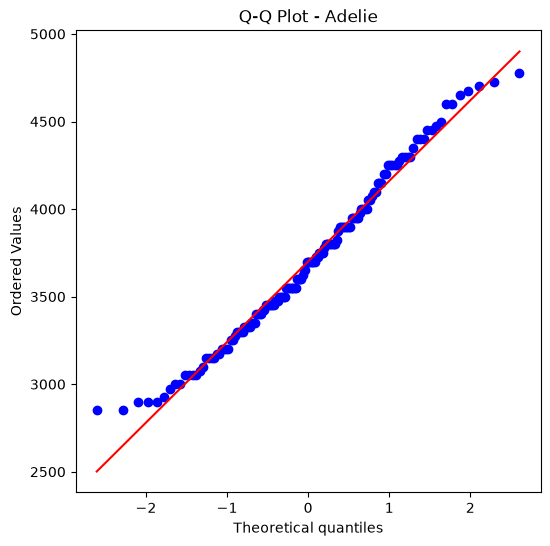

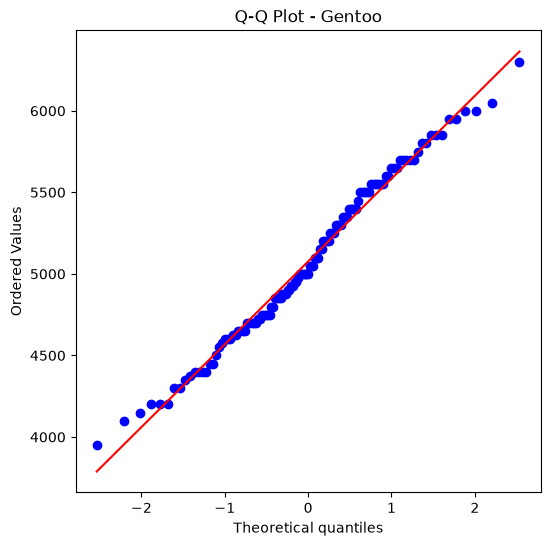

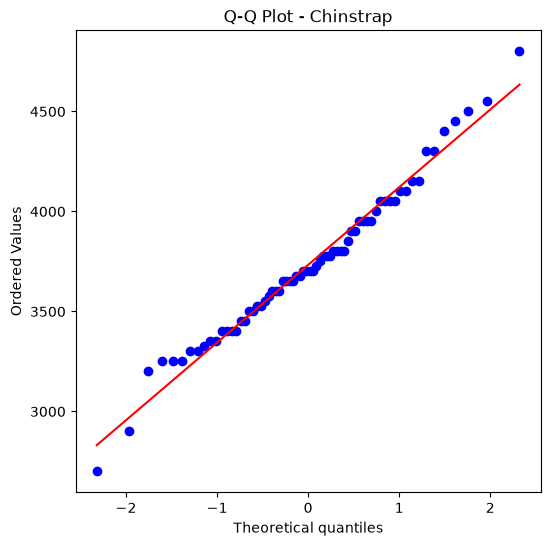

In [99]:
# Gráfico de Q-Q para cada especie

for species in species_list:

    x = penguins.loc[
        penguins["species"] == species,
        "body_mass_g"
    ].dropna()

    plt.figure(figsize=(6, 6))

    stats.probplot(
        x,
        dist="norm",
        plot=plt
    )

    plt.title(f"Q-Q Plot - {species}")

    plt.show()

Se rechaza la hipotesís nula (HO). La prueba Shapiro-Wilk nos proporciona evidencia estadísticamente significativa de que la masa corporal de los pingüinos Adelie no sigue exactamente una distribución normal. En el grupo Adelie se detecta uan desviacion significa en la normalidad p=0.0324,  observando las graficas de Q-Q plot  observamos que existe una pequeña desviación en las colas, pero aún asi siguen la recta razonablemnte.

In [100]:
# 5. Determina, mediante una prueba de hipótesis, si la masa corporal media de los pingüinos Adelie es diferente de 3800 g.

adelie = penguins.loc[
    penguins["species"] == "Adelie",
    "body_mass_g"
].dropna()

mu_0 = 3800
alpha = 0.05

# estadísticas de la muestra
n = len(adelie)
x_bar = np.mean(adelie)
s = np.std(adelie, ddof=1)

se = s / np.sqrt(n)

# t estadístico
t_stat = (x_bar - mu_0) / se

df = n - 1

# p-value
p_value = 2 * (
    1 - stats.t.cdf(abs(t_stat), df)
)

# valor crítico 
t_critical = stats.t.ppf(
    1 - alpha/2,
    df
)

print("n =", n)
print("Promedio de la muestra  =", x_bar)
print("Desviación estándar de la muestra =", s)
print("Error estándar =", se)

print("estadistico t  =", t_stat)
print("Grados de libertad =", df)
print("Critical value =", t_critical)
print("p-value =", p_value)

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")

n = 151
Promedio de la muestra  = 3700.662251655629
Desviación estándar de la muestra = 458.5661259101348
Error estándar = 37.317582084907
estadistico t  = -2.661955646492646
Grados de libertad = 150
Critical value = 1.9759053308966201
p-value = 0.00861583645328512
Reject H0


Se rechaza la hipótesis nula a un nivel de significancia de 0.05 (t=-2.662, p=0.0086). Existe evidencia estadísticamente significativa de que la masa corporal media de los pingüinos Adelie es diferente de 3800 g. La media observada fue de 3700.66 g, por lo que en la muestra la masa media fue aproximadamente 99.34 g menor que 3800 g.

In [101]:
# 6. Determina si existen diferencias significativas en la masa corporal media entre las tres especies.

## Preparamos datos para la prueba ANOVA 
adelie = penguins.loc[
    penguins["species"] == "Adelie",
    "body_mass_g"
].dropna()

chinstrap = penguins.loc[
    penguins["species"] == "Chinstrap",
    "body_mass_g"
].dropna()

gentoo = penguins.loc[
    penguins["species"] == "Gentoo",
    "body_mass_g"
].dropna()

In [102]:
# Prueba de Levene para la homogeneidad de varianzas
levene_stat, levene_p = stats.levene(
    adelie,
    chinstrap,
    gentoo
)

print("Levene estadístico =", levene_stat)
print("p-value =", levene_p)

Levene estadístico = 5.12025099751946
p-value = 0.006445082805324017


In [103]:
# ANOVA de una variabñe

alpha = 0.05

f_stat, p_value = stats.f_oneway(
    adelie,
    chinstrap,
    gentoo
)

k = 3

n_total = (
    len(adelie)
    + len(chinstrap)
    + len(gentoo)
)

df_between = k - 1
df_within = n_total - k

f_critical = stats.f.ppf(
    1 - alpha,
    df_between,
    df_within
)

print("Mean Adelie =", np.mean(adelie))
print("Mean Chinstrap =", np.mean(chinstrap))
print("Mean Gentoo =", np.mean(gentoo))

print()

print(
    "Desviación estándar Adelie =",
    np.std(adelie, ddof=1)
)

print(
    "Desviación estándar Chinstrap =",
    np.std(chinstrap, ddof=1)
)

print(
    "Desviación estándar Gentoo =",
    np.std(gentoo, ddof=1)
)

print()

print("F statistic =", f_stat)

print(
    "Grados de libertad entre grupos =",
    df_between
)

print(
    "Grados de libertad dentro de los grupos =",
    df_within
)

print("Valor crítico =", f_critical)
print("p-value =", p_value)

if p_value < alpha:
    print("Rechazamos H0")
else:
    print("Fallo en recharzar H0")

Mean Adelie = 3700.662251655629
Mean Chinstrap = 3733.0882352941176
Mean Gentoo = 5076.016260162602

Desviación estándar Adelie = 458.5661259101348
Desviación estándar Chinstrap = 384.3350813871914
Desviación estándar Gentoo = 504.11623665709163

F statistic = 343.626275205481
Grados de libertad entre grupos = 2
Grados de libertad dentro de los grupos = 339
Valor crítico = 3.0223621182600793
p-value = 2.8923681333772844e-82
Rechazamos H0


In [108]:
# Utilizamos Krustall Walllis para comparar las tres especies

alpha = 0.05

h_stat, p_value = stats.kruskal(
    adelie,
    chinstrap,
    gentoo
)

print("H statistic =", h_stat)
print("p-value =", p_value)

if p_value < alpha:
    print("Rechazamos H0")
else:
    print("No rechazamos H0")

H statistic = 217.59924143680436
p-value = 5.609512095829062e-48
Rechazamos H0


Dado que la prueba de Levene indicó que no se cumple el supuesto de homogeneidad de varianzas y que para Adelie se detectó una desviación de la normalidad, se aplicó la prueba de Kruskal–Wallis. El resultado fue (H=217.599) con (p=5.61\times10^-48), por lo que se rechaza la hipótesis nula. Existe evidencia estadísticamente significativa de que la distribución de la masa corporal difiere entre al menos dos de las tres especies.

In [ ]:
# 7. Considerando únicamente a los pingüinos Adelie, determina si existen diferencias significativas en la masa corporal media entre las islas Biscoe, Dream y Torgersen.

## Preparacion de los datos

adelie_data = penguins[
    penguins["species"] == "Adelie"
]

biscoe = adelie_data.loc[
    adelie_data["island"] == "Biscoe",
    "body_mass_g"
].dropna()

dream = adelie_data.loc[
    adelie_data["island"] == "Dream",
    "body_mass_g"
].dropna()

torgersen = adelie_data.loc[
    adelie_data["island"] == "Torgersen",
    "body_mass_g"
].dropna()

# Tamaño de muestra
print("Biscoe n =", len(biscoe))
print("Dream n =", len(dream
print("Torgersen n =", len(torgersen

Biscoe n = 44
Dream n = 56
Torgersen n = 51


In [107]:
levene_stat, levene_p = stats.levene(
    biscoe,
    dream,
    torgersen
)

print("Estadistico Levene =", levene_stat)
print("p-value =", levene_p)

Estadistico Levene = 0.10988874158240455
p-value = 0.8960068411620024


In [ ]:
# Anova de una variable
alpha = 0.05

f_stat, p_value = stats.f_oneway(
    biscoe,
    dream,
    torgersen
)

k = 3

n_total = (
    len(biscoe)
    + len(dream)
    + len(torgersen)
)

df_between = k - 1
df_within = n_total - k

f_critical = stats.f.ppf(
    1 - alpha,
    df_between,
    df_within
)

print("Promedio Biscoe =", np.mean(biscoe
print("Promedio Dream =", np.mean(dream
print("Promedio Torgersen =", np.mean(torgersen

print()

print("F statistic =", f_stat)

print(
    "Grados de libertad entre grupos =",
    df_between
)

print(
    "Grados de libertad dentro de los grupos =",
    df_within
)

print("Valor crítico =", f_critical)
print("p-value =", p_value)

if p_value < alpha:
    print("Rechazamos H0")
else:
    print("Fallo en rechazar H0")

Promedio Biscoe = 3709.659090909091
Promedio Dream = 3688.3928571428573
Promedio Torgersen = 3706.372549019608

F statistic = 0.03204821591407109
Grados de libertad entre grupos = 2
Grados de libertad dentro de los grupos = 148
Valor crítico = 3.057196806053664
p-value = 0.9684666047614288
Fallo en rechazar H0


La prueba de Levene no encontró evidencia de diferencias significativas entre las varianzas de las tres islas (p=0.8960), por lo que el supuesto de homogeneidad de varianzas resulta razonable. Posteriormente, el ANOVA de un factor no encontró diferencias estadísticamente significativas en la masa corporal media de los pinguinos Adelie entre Biscoe, Dream y Torgersen (F=0.0320,\ p=0.9685). Por lo tanto, *no se rechaza la hipótesis nula* de igualdad de medias.

In [ ]:
# 8.Analiza la masa corporal considerando simultáneamente los factores especie y sexo. Determina si existe un efecto significativo de la especie, un efecto significativo del sexo y una interacción significativa entre ambos factores.


# Prepation de los datos

anova_data = penguins[
    ["body_mass_g", "species", "sex"]
].dropna()

anova_data.groupby(
    ["species", "sex"]
)["body_mass_g"].agg(
    ["count", "mean", "std"]
)

count         mean         std
species   sex                                   
Adelie    female     73  3368.835616  269.380102
          male       73  4043.493151  346.811553
Chinstrap female     34  3527.205882  285.333912
          male       34  3938.970588  362.137550
Gentoo    female     58  4679.741379  281.578294
          male       61  5484.836066  313.158596

In [90]:
## Anova de 2 variables

model = ols(
    "body_mass_g ~ C(species) * C(sex)",
    data=anova_data
).fit()

anova_table = sm.stats.anova_lm(
    model,
    typ=2
)

anova_table

,sum_sq,df,F,PR(>F)
C(species),1.434016e+08,2.0,749.015666,8.144406e-123
C(sex),3.709026e+07,1.0,387.459976,1.902273e-57
C(species):C(sex),1.676557e+06,2.0,8.756997,1.973489e-04
Residual,3.130263e+07,327.0,NaN,NaN


In [91]:
mean_table = (
    anova_data
    .groupby(["species", "sex"])["body_mass_g"]
    .mean()
    .unstack()
)

mean_table

sex,female,male
species,,
Adelie,3368.835616,4043.493151
Chinstrap,3527.205882,3938.970588
Gentoo,4679.741379,5484.836066


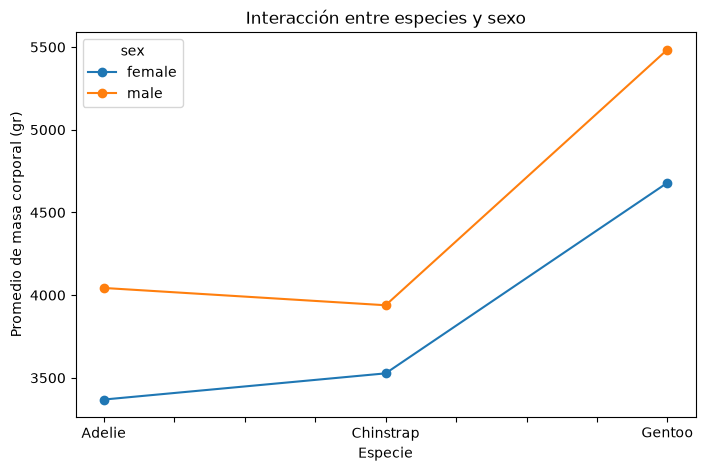

In [92]:
mean_table.plot(
    marker="o",
    figsize=(8, 5)
)

plt.xlabel("Especie")
plt.ylabel("Promedio de masa corporal (gr)")
plt.title("Interacción entre especies y sexo")

plt.show()

El ANOVA de dos factores mostró un efecto estadísticamente significativo de la especie sobre la masa corporal (F=749.016, p<0.001) y un efecto estadísticamente significativo del sexo (F=387.460, p<0.001). Además se encontró una interacción estadísticamente significativa entre especie y sexo (F=8.757, p<0.001). Por lo tanto, el efecto del sexo sobre la masa corporal no es igual para todas las especies. Esto también se observa gráficamente, ya que las diferencias entre machos y hembras son aproximadamente 674.66 g en Adelie, 411.76 g en Chinstrap y 805.09 g en Gentoo.

### B. Longitud de la aleta

Analiza la variable longitud de la aleta (flipper_length_mm):


In [124]:
# 1. Estima mediante intervalos de confianza del 95 % la longitud media de la aleta para cada especie.


species_list = penguins["species"].unique()

cl = 0.95
alpha = 1 - cl

for species in species_list:
    x = penguins.loc[
        penguins["species"] == species,
        "flipper_length_mm"
    ].dropna()

    # Muestra 
    sample_mean = np.mean(x)
    sample_std_dev = np.std(x, ddof=1)
    sample_size = len(x)

    # Valor crítico de la distribución t
    t_score = stats.t.ppf(
        1 - alpha/2,
        df=sample_size - 1
    )

    # Margen de error
    margin_of_error = (
        t_score
        * sample_std_dev
        / np.sqrt(sample_size)
    )

    # Intervalo de confianza
    confidence_interval = (
        sample_mean - margin_of_error,
        sample_mean + margin_of_error
    )

    print(species)
    print("Sample size =", sample_size)
    print("Sample mean =", sample_mean)
    print("Desviación estándar de la muestra =", sample_std_dev)
    print("95% Intervalo de confianza =", confidence_interval)
    print()

Adelie
Sample size = 151
Sample mean = 189.95364238410596
Desviación estándar de la muestra = 6.539457417191298
95% Intervalo de confianza = (np.float64(188.90211793388121), np.float64(191.0051668343307))

Gentoo
Sample size = 123
Sample mean = 217.1869918699187
Desviación estándar de la muestra = 6.484975818673946
95% Intervalo de confianza = (np.float64(216.0294592893067), np.float64(218.3445244505307))

Chinstrap
Sample size = 68
Sample mean = 195.8235294117647
Desviación estándar de la muestra = 7.131894258578147
95% Intervalo de confianza = (np.float64(194.0972432317915), np.float64(197.54981559173788))



Con un nivel de confianza del 95%, la longitud media de la aleta de los pingüinos Adelie se estima entre 188.9021 mm y 191.0051 mm, la de Gentoo entre 216.0294 mm y 218.3445 mm, y la de Chinstrap entre 194.0972 mm y 197.5498 mm. Descriptivamente, Gentoo presenta la mayor longitud media de aleta, seguido de Chinstrap y Adelie.

In [125]:
# 2. Construye un intervalo de confianza para la diferencia en la longitud media de la aleta entre Gentoo y Adelie.


gentoo = penguins.loc[
    penguins["species"] == "Gentoo",
    "flipper_length_mm"
].dropna()

adelie = penguins.loc[
    penguins["species"] == "Adelie",
    "flipper_length_mm"
].dropna()

cl = 0.95
alpha = 1 - cl

# Estadisticos de muestra
mean_gentoo = np.mean(gentoo)
std_gentoo = np.std(gentoo, ddof=1)
n_gentoo = len(gentoo)

mean_adelie = np.mean(adelie)
std_adelie = np.std(adelie, ddof=1)
n_adelie = len(adelie)

# Error estándar
standard_error_diff = np.sqrt(
    std_gentoo**2 / n_gentoo +
    std_adelie**2 / n_adelie
)

# grados de libertad de Welch-Satterthwaite
df = (
    std_gentoo**2 / n_gentoo +
    std_adelie**2 / n_adelie
)**2 / (
    (std_gentoo**2 / n_gentoo)**2 / (n_gentoo - 1)
    +
    (std_adelie**2 / n_adelie)**2 / (n_adelie - 1)
)

# Valor crítico de la distribución t
t_score = stats.t.ppf(
    1 - alpha/2,
    df=df
)

# Margen de error
margin_of_error = (
    t_score * standard_error_diff
)

# Intervalo de confianza para la diferencia de medias
mean_diff = mean_gentoo - mean_adelie

confidence_interval_diff = (
    mean_diff - margin_of_error,
    mean_diff + margin_of_error
)

print("Gentoo sample size =", n_gentoo)
print("Adelie sample size =", n_adelie)

print("Gentoo mean =", mean_gentoo)
print("Adelie mean =", mean_adelie)

print("Diferencia Gentoo - Adelie =", mean_diff)
print("Grados de libertad =", df)

print(
    "95% Intervalo de confianza Gentoo - Adelie =",
    confidence_interval_diff
)

Gentoo sample size = 123
Adelie sample size = 151
Gentoo mean = 217.1869918699187
Adelie mean = 189.95364238410596
Diferencia Gentoo - Adelie = 27.233349485812738
Grados de libertad = 261.7490970865337
95% Intervalo de confianza Gentoo - Adelie = (np.float64(25.676516632766035), np.float64(28.79018233885944))


La longitud media de la aleta de los pingüinos Gentoo fue aproximadamente 27.23 mm mayor que la de los pinguinos Adelie. Con un nivel de confianza del 95%, la diferencia poblacional se estima entre 25.68 mm y 28.79 mm. Como el intervalo no contiene el valor 0 y es completamente positivo, hay evidencia de que Gentoo tiene una longitud media de aleta mayor que Adelie.

In [126]:
# 3. Evalúa si la longitud media de la aleta de los pingüinos Gentoo es mayor que 210 mm.

gentoo = penguins.loc[
    penguins["species"] == "Gentoo",
    "flipper_length_mm"
].dropna()

mu_0 = 210
alpha = 0.05

# Estadisticos de muestra
n = len(gentoo)
x_bar = np.mean(gentoo)
s = np.std(gentoo, ddof=1)

se = s / np.sqrt(n)

# t estadístico
t_stat = (x_bar - mu_0) / se

df = n - 1

# P-value para una prueba de cola derecha
p_value = 1 - stats.t.cdf(
    t_stat,
    df
)

# valor crítico para prueba de cola derecha
t_critical = stats.t.ppf(
    1 - alpha,
    df
)

print("n =", n)
print("Sample mean =", x_bar)
print("Desviación estándar de la muestra =", s)
print("Error estándar =", se)

print("t estadístico =", t_stat)
print("Grados de libertad =", df)
print("Valor crítico =", t_critical)
print("p-value =", p_value)

if p_value < alpha:
    print("Rechazamos H0")
else:
    print("No rechazamos H0")

n = 123
Sample mean = 217.1869918699187
Desviación estándar de la muestra = 6.484975818673946
Error estándar = 0.584730577725087
t estadístico = 12.291116872799643
Grados de libertad = 122
Valor crítico = 1.6574394994074138
p-value = 0.0
Rechazamos H0


Se rechaza H0 a un nivel de significancia de 0.05 (t=12.291, p<0.001). Existe evidencia significativa de que la longitud media de la aleta de los pinguinos Gentoo es mayor que 210 mm. La media observada fue de 217.19 mm.

In [127]:
# 4. Evalúa el supuesto de normalidad de la longitud de la aleta para cada especie mediante una prueba de normalidad apropiada. Complementa el resultado con una inspección gráfica, por ejemplo mediante histogramas o gráficos Q–Q.

# Shapiro-Wilk test de normalidad

alpha = 0.05

species_list = penguins["species"].unique()

for species in species_list:

    x = penguins.loc[
        penguins["species"] == species,
        "flipper_length_mm"
    ].dropna()

    shapiro_stat, p_value = stats.shapiro(x)

    print(species)
    print("n =", len(x))
    print("Shapiro-Wilk estadístico =", shapiro_stat)
    print("p-value =", p_value)

    if p_value < alpha:
        print("Rechazamos H0: evidencia en contra de la normalidad")
    else:
        print("No rechazamos H0: la normalidad es razonable")

    print()

Adelie
n = 151
Shapiro-Wilk estadístico = 0.9933915644908098
p-value = 0.7200466172067743
No rechazamos H0: la normalidad es razonable

Gentoo
n = 123
Shapiro-Wilk estadístico = 0.962193576023633
p-value = 0.0016198141092087276
Rechazamos H0: evidencia en contra de la normalidad

Chinstrap
n = 68
Shapiro-Wilk estadístico = 0.9889114829057272
p-value = 0.8106446591552412
No rechazamos H0: la normalidad es razonable



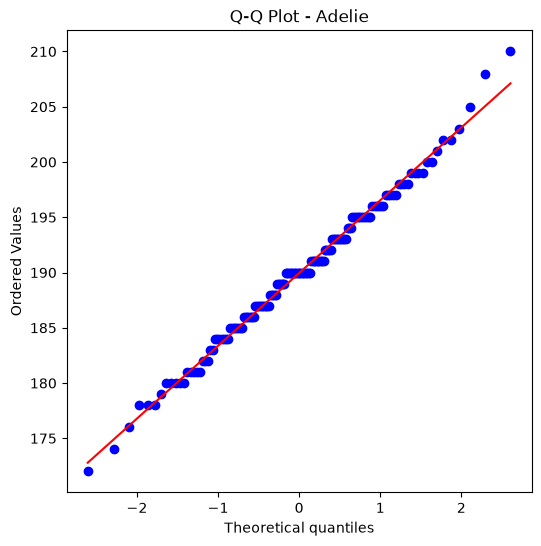

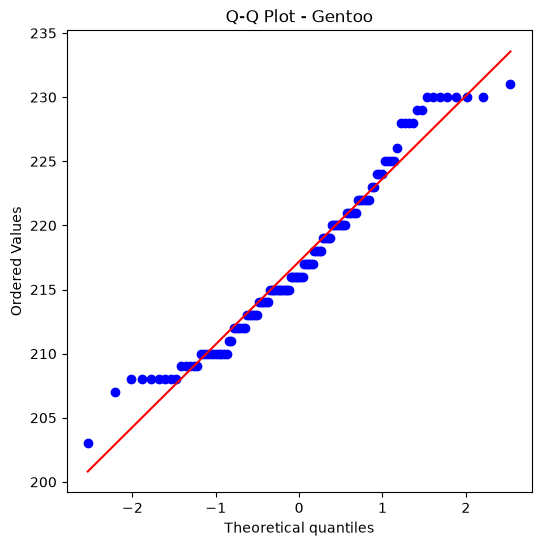

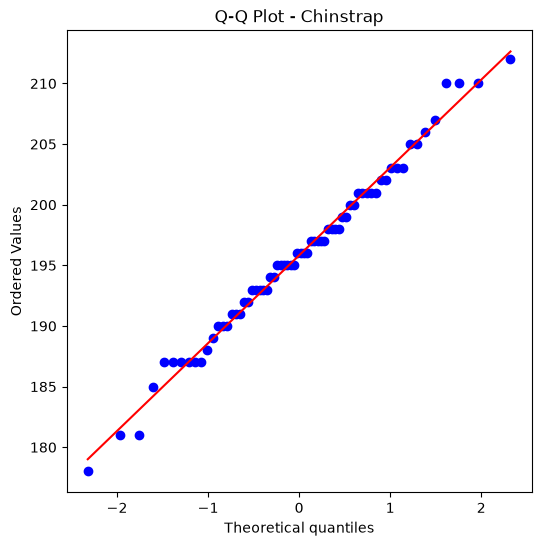

In [128]:
# Gráfico de Q-Q para cada especie

for species in species_list:

    x = penguins.loc[
        penguins["species"] == species,
        "flipper_length_mm"
    ].dropna()

    plt.figure(figsize=(6, 6))

    stats.probplot(
        x,
        dist="norm",
        plot=plt
    )

    plt.title(
        f"Q-Q Plot - {species}"
    )

    plt.show()

No se rechaza la hipotesis nula de normalidad. Aunque Shapiro-Wilk detectó una desviación estadísticamente significativa de la normalidad para Gentoo (p=0.0016). El gráfico Q-Q muestra una relación aproximadamente lineal en la parte central de la distribución, con desviaciones principalmente en las colas. 
Para Adelie y Chinstrap no se encontró evidencia  significativa contra el supuesto de normalidad (p=0.7200 y p=0.8106), respectivamente. 

In [130]:
# 5. Determina si existen diferencias significativas en la longitud media de la aleta entre las tres especies.

# Preparamos los datos para la prueba ANOVA

adelie = penguins.loc[
    penguins["species"] == "Adelie",
    "flipper_length_mm"
].dropna()

chinstrap = penguins.loc[
    penguins["species"] == "Chinstrap",
    "flipper_length_mm"
].dropna()

gentoo = penguins.loc[
    penguins["species"] == "Gentoo",
    "flipper_length_mm"
].dropna()

In [131]:
# Levene test

levene_stat, levene_p = stats.levene(
    adelie,
    chinstrap,
    gentoo
)

print("Levene estadístico =", levene_stat)
print("p-value =", levene_p)

Levene estadístico = 0.3305621020326624
p-value = 0.7187510785544903


In [132]:
# ANOVA de una variable

alpha = 0.05

f_stat, p_value = stats.f_oneway(
    adelie,
    chinstrap,
    gentoo
)

k = 3

n_total = (
    len(adelie)
    + len(chinstrap)
    + len(gentoo)
)

df_between = k - 1
df_within = n_total - k

f_critical = stats.f.ppf(
    1 - alpha,
    df_between,
    df_within
)

print("Mean Adelie =", np.mean(adelie))
print("Mean Chinstrap =", np.mean(chinstrap))
print("Mean Gentoo =", np.mean(gentoo))

print()

print(
    "Desviación estándar Adelie =",
    np.std(adelie, ddof=1)
)

print(
    "Desviación estándar Chinstrap =",
    np.std(chinstrap, ddof=1)
)

print(
    "Desviación estándar Gentoo =",
    np.std(gentoo, ddof=1)
)

print()

print("F statistic =", f_stat)
print(
    "Grados de libertad entre grupos =",
    df_between
)
print(
    "Grados de libertad dentro de los grupos =",
    df_within
)

print("Valor crítico =", f_critical)
print("p-value =", p_value)

if p_value < alpha:
    print("Rechazamos H0")
else:
    print("No rechazamos H0")

Mean Adelie = 189.95364238410596
Mean Chinstrap = 195.8235294117647
Mean Gentoo = 217.1869918699187

Desviación estándar Adelie = 6.539457417191298
Desviación estándar Chinstrap = 7.131894258578147
Desviación estándar Gentoo = 6.484975818673946

F statistic = 594.801627438516
Grados de libertad entre grupos = 2
Grados de libertad dentro de los grupos = 339
Valor crítico = 3.0223621182600793
p-value = 1.3517103385733743e-111
Rechazamos H0


La prueba de Levene no encontró evidencia de diferencias significativas entre las varianzas de las tres especies (p=0.7187), por lo que el supuesto de homogeneidad de varianzas es aceptable. Aunque Shapiro-Wilk rechazó normalidad para Gentoo, el tamaño muestral es grande y la homogeneidad de varianzas se cumple, por lo que se mantuvo el ANOVA como análisis principal.

El ANOVA de un factor mostró diferencias estadísticamente significativas en la longitud media de la aleta entre las tres especies (F=594.8016, p<0.001). Por lo tanto, se rechaza la hipótesis nula de igualdad de medias.

In [133]:
# 6. Analiza la longitud media de la aleta considerando simultáneamente los factores especie y sexo. Determina si existe un efecto significativo de la especie, un efecto significativo del sexo y una interacción significativa entre ambos factores.

# Preparación de los datos


anova_data_flipper = penguins[
    ["flipper_length_mm", "species", "sex"]
].dropna()

anova_data_flipper.groupby(
    ["species", "sex"]
)["flipper_length_mm"].agg(
    ["count", "mean", "std"]
)

count        mean       std
species   sex                                
Adelie    female     73  187.794521  5.595035
          male       73  192.410959  6.599317
Chinstrap female     34  191.735294  5.754096
          male       34  199.911765  5.976558
Gentoo    female     58  212.706897  3.897856
          male       61  221.540984  5.673252

In [134]:
# ANoVA de dos variables

model = ols(
    "flipper_length_mm ~ C(species) * C(sex)",
    data=anova_data_flipper
).fit()

anova_table = sm.stats.anova_lm(
    model,
    typ=2
)

anova_table

,sum_sq,df,F,PR(>F)
C(species),50185.026617,2.0,784.582911,1.569568e-125
C(sex),3905.603773,1.0,122.118894,2.461150e-24
C(species):C(sex),329.042484,2.0,5.144186,6.314424e-03
Residual,10458.106765,327.0,NaN,NaN


In [135]:
# Interaction plot

mean_table_flipper = (
    anova_data_flipper
    .groupby(
        ["species", "sex"]
    )["flipper_length_mm"]
    .mean()
    .unstack()
)

mean_table_flipper

sex,female,male
species,,
Adelie,187.794521,192.410959
Chinstrap,191.735294,199.911765
Gentoo,212.706897,221.540984


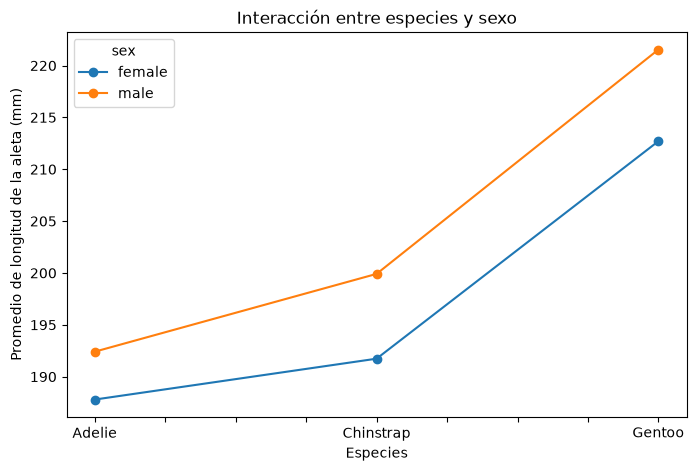

In [136]:
mean_table_flipper.plot(
    marker="o",
    figsize=(8, 5)
)

plt.xlabel("Especies")
plt.ylabel(
    "Promedio de longitud de la aleta (mm)"
)
plt.title(
    "Interacción entre especies y sexo"
)

plt.show()

 ANOVA factorial mostró un efecto significativo de la especie sobre la longitud de la aleta (F=784.583,p<0.001) y un efecto estadísticamente significativo del sexo (F=122.119, p<0.001). Además, se encontró una interacción estadísticamente significativa entre especie y sexo (F=5.144, p=0.0063). Por lo tanto, el efecto del sexo sobre la longitud de la aleta depende de la especie. Podemos decir que los machos presentan aletas más largas que las hembras en las tres especies, pero la magnitud de esta diferencia varía entre ellas.

### C. Longitud y profundidad del pico

Utilizando las variables bill_length_mm y bill_depth_mm:



In [ ]:
# 1. Construye intervalos de confianza del 95 % para la longitud media y la profundidad media del pico.


x = penguins["bill_length_mm"].dropna()

cl = 0.95
alpha = 1 - cl

sample_mean = np.mean(x)
sample_std_dev = np.std(x, ddof=1)
sample_size = len(x)

t_score = stats.t.ppf(
    1 - alpha/2,
    df=sample_size - 1
)

margin_of_error = (
    t_score

    * sample_std_dev
    / np.sqrt(sample_size)
)

confidence_interval = (
    sample_mean - margin_of_error,
    sample_mean + margin_of_error
)

print("Sample size =", sample_size)
print("Sample mean =", sample_mean)
print("Desviacion estandar de la muestra =", sample_std_dev)
print("Intervalo de confianza 95% =", confidence_interval)

Sample size = 342
Sample mean = 43.9219298245614
Desviacion estandar de la muestra = 5.4595837139265315
Intervalo de confianza 95% = (np.float64(43.34124734665461), np.float64(44.502612302468194))


In [145]:
# Intervalo de confianza para la profundidad del pico
x = penguins["bill_depth_mm"].dropna()

cl = 0.95
alpha = 1 - cl

sample_mean = np.mean(x)
sample_std_dev = np.std(x, ddof=1)
sample_size = len(x)

t_score = stats.t.ppf(
    1 - alpha/2,
    df=sample_size - 1
)

margin_of_error = (
    t_score
    * sample_std_dev
    / np.sqrt(sample_size)
)

confidence_interval = (
    sample_mean - margin_of_error,
    sample_mean + margin_of_error
)

print("Sample size =", sample_size)
print("Sample mean =", sample_mean)
print("Desviacion estandar de la muestra =", sample_std_dev)
print("95% Intervalo de Confianza  =", confidence_interval)

Sample size = 342
Sample mean = 17.151169590643274
Desviacion estandar de la muestra = 1.9747931568167814
95% Intervalo de Confianza  = (np.float64(16.94113017303555), np.float64(17.361209008251))


Con un nivel de confianza del 95%, la longitud media poblacional del pico se estima entre 43.3412 mm y 44.5026 mm, con una media muestral de 43.9219 mm. Por otra parte, la profundidad media poblacional del pico se estima entre 16.9411 mm y 17.3612 mm, con una media muestral de 17.1511 mm.

In [ ]:
# 2. Construye intervalos de confianza para la diferencia de medias entre machos y hembras en ambas características.


male = penguins.loc[
    penguins["sex"] == "male",
    "bill_length_mm"
].dropna()

female = penguins.loc[
    penguins["sex"] == "female",
    "bill_length_mm"
].dropna()

cl = 0.95
alpha = 1 - cl

mean_male = np.mean(male)
std_male = np.std(male, ddof=1)
n_male = len(male)

mean_female = np.mean(female)
std_female = np.std(female, ddof=1)
n_female = len(female)

standard_error_diff = np.sqrt(
    std_male**2 / n_male +
    std_female**2 / n_female
)

df = (
    std_male**2 / n_male +
    std_female**2 / n_female
)**2 / (
    (std_male**2 / n_male)**2 / (n_male - 1)
    +
    (std_female**2 / n_female)**2 / (n_female - 1)
)

t_score = stats.t.ppf(
    1 - alpha/2,
    df=df
)

margin_of_error = (
    t_score * standard_error_diff
)

mean_diff = mean_male - mean_female

confidence_interval = (
    mean_diff - margin_of_error,
    mean_diff + margin_of_error
)

print("Male mean =", mean_male)
print("Female mean =", mean_female)
print("Diferencia entre macho - hembra =", mean_diff)
print("Grados de libertad =", df)
print("95% Intervalo de Confianza  =", confidence_interval)

Male mean = 45.85476190476191
Female mean = 42.096969696969694
Difference male - female = 3.757792207792214
Degrees of freedom = 329.29025630403345
95% Confidence Interval = (np.float64(2.649908112181555), np.float64(4.865676303402873))


In [166]:
# Intervalo de confianza para la profundidad del pico m y h 
male = penguins.loc[
    penguins["sex"] == "male",
    "bill_depth_mm"
].dropna()

female = penguins.loc[
    penguins["sex"] == "female",
    "bill_depth_mm"
].dropna()

cl = 0.95
alpha = 1 - cl

mean_male = np.mean(male)
std_male = np.std(male, ddof=1)
n_male = len(male)

mean_female = np.mean(female)
std_female = np.std(female, ddof=1)
n_female = len(female)

standard_error_diff = np.sqrt(
    std_male**2 / n_male +
    std_female**2 / n_female
)

df = (
    std_male**2 / n_male +
    std_female**2 / n_female
)**2 / (
    (std_male**2 / n_male)**2 / (n_male - 1)
    +
    (std_female**2 / n_female)**2 / (n_female - 1)
)

t_score = stats.t.ppf(
    1 - alpha/2,
    df=df
)

margin_of_error = (
    t_score * standard_error_diff
)

mean_diff = mean_male - mean_female

confidence_interval = (
    mean_diff - margin_of_error,
    mean_diff + margin_of_error
)

print("Male mean =", mean_male)
print("Female mean =", mean_female)
print("Diferecia macho - hembra =", mean_diff)
print("Grados de libertad =", df)
print("95% Intervalo de Confianza  =", confidence_interval)

Male mean = 17.89107142857143
Female mean = 16.425454545454546
Diferecia macho - hembra = 1.4656168831168834
Grados de libertad = 330.88164636851224
95% Intervalo de Confianza  = (np.float64(1.0711567449291852), np.float64(1.8600770213045816))


Con un nivel de confianza del 95%, se estima que la profundidad media del pico de los machos es entre 1.07 mm y 1.86 mm mayor que la de las hembras. La longitud media del pico observada fue de 45.85 mm en machos y 42.10 mm en hembras, con una diferencia estimada de 3.76 mm. La diferencia media estimada fue de 1.47 mm. Como el intervalo de confianza no contiene 0, los resultados proporcionan evidencia de una diferencia en la profundidad media del pico entre ambos sexos, siendo mayor en los machos.

#### 3.  Evalúa el supuesto de normalidad de la longitud media del pico para cada especie mediante una prueba de normalidad apropiada. Complementa el resultado con una inspección gráfica, por ejemplo mediante histogramas o gráficos Q–Q.


In [ ]:

# shapiro-Wilk lenght del pico

alpha = 0.05

species_list = penguins["species"].unique()

for species in species_list:

    x = penguins.loc[
        penguins["species"] == species,
        "bill_length_mm"
    ].dropna()

    shapiro_stat, p_value = stats.shapiro(x)

    print(species)
    print("n =", len(x))
    print("Shapiro-Wilk statistic =", shapiro_stat)
    print("p-value =", p_value)

    if p_value < alpha:
        print("Rechazar H0: evidencia en contra de la normalidad")
    else:
        print("Fallamos en rechazar H0")

    print()

Adelie
n = 151
Shapiro-Wilk statistic = 0.9933617523306832
p-value = 0.7166005442140255
Fallamos en rechazar H0

Gentoo
n = 123
Shapiro-Wilk statistic = 0.9727224330200134
p-value = 0.013491432298349013
Rechazar H0: evidencia en contra de la normalidad

Chinstrap
n = 68
Shapiro-Wilk statistic = 0.9752496075089336
p-value = 0.1940925730703269
Fallamos en rechazar H0



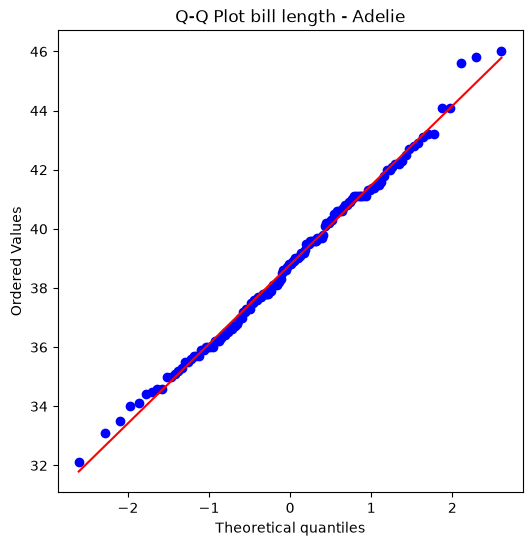

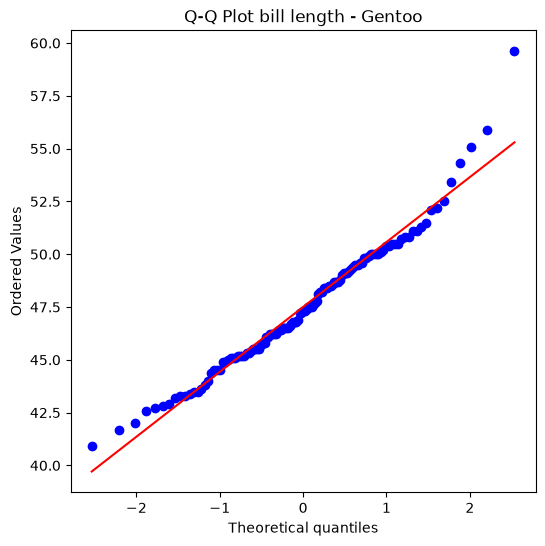

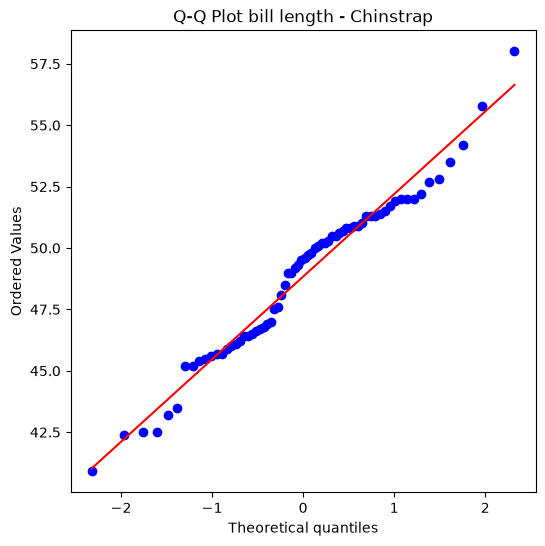

In [143]:
# Q-Q plot for bill length

for species in species_list:

    x = penguins.loc[
        penguins["species"] == species,
        "bill_length_mm"
    ].dropna()

    plt.figure(figsize=(6, 6))

    stats.probplot(
        x,
        dist="norm",
        plot=plt
    )

    plt.title(
        f"Q-Q Plot bill length - {species}"
    )

    plt.show()

De acuerdo con Shapiro-Wilk, Adelie y Chinstrap son compatibles con el supuesto de normalidad, mientras que Gentoo presenta evidencia estadísticamente significativa de desviación de la normalidad (p=0.0135). La inspección gráfica coincide en que Gentoo presenta las desviaciones más notorias, principalmente en la cola superior.

In [169]:
# 4. Evalúa el supuesto de normalidad de la profundidad media del pico para cada especie mediante una prueba de normalidad apropiada. Complementa el resultado con una inspección gráfica, por ejemplo mediante histogramas o gráficos Q–Q.

# Shapiro-Wilk 

alpha = 0.05

for species in species_list:

    x = penguins.loc[
        penguins["species"] == species,
        "bill_depth_mm"
    ].dropna()

    shapiro_stat, p_value = stats.shapiro(x)

    print(species)
    print("n =", len(x))
    print("Shapiro-Wilk statistic =", shapiro_stat)
    print("p-value =", p_value)

    if p_value < alpha:
        print("Rechazar H0: evidencia en contra de la normalidad")
    else:
        print("Fallar en rechazar H0: la normalidad es razonable")

    print()

Adelie
n = 151
Shapiro-Wilk statistic = 0.984668318576196
p-value = 0.09248966204943865
Fallar en rechazar H0: la normalidad es razonable

Gentoo
n = 123
Shapiro-Wilk statistic = 0.9760938150858313
p-value = 0.02769509460895462
Rechazar H0: evidencia en contra de la normalidad

Chinstrap
n = 68
Shapiro-Wilk statistic = 0.9727431839564323
p-value = 0.14178462778534018
Fallar en rechazar H0: la normalidad es razonable



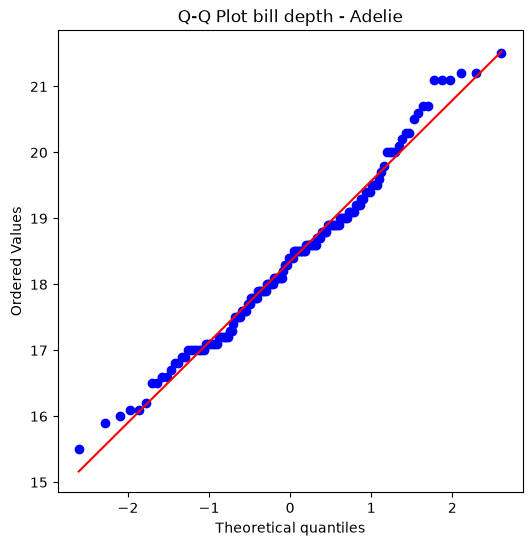

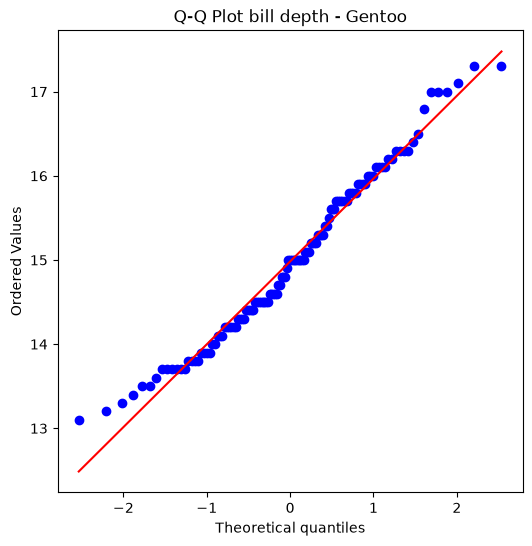

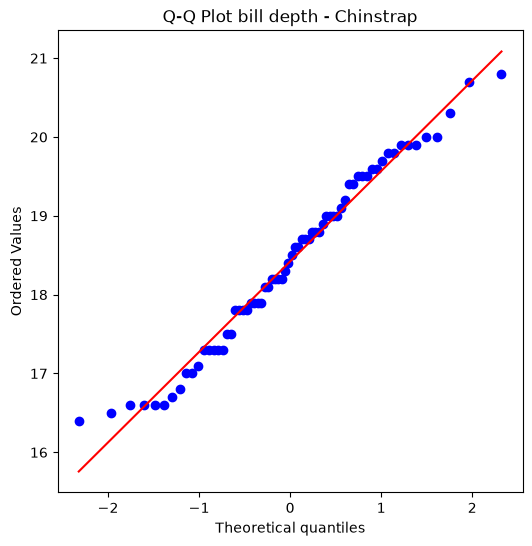

In [168]:
for species in species_list:

    x = penguins.loc[
        penguins["species"] == species,
        "bill_depth_mm"
    ].dropna()

    plt.figure(figsize=(6, 6))

    stats.probplot(
        x,
        dist="norm",
        plot=plt
    )

    plt.title(
        f"Q-Q Plot bill depth - {species}"
    )

    plt.show()

De acuerdo con la prueba de Shapiro-Wilk, no se encontró evidencia estadísticamente significativa en contra del supuesto de normalidad para Adelie (p=0.0925) ni Chinstrap (p=0.1418). Para Gentoo, la prueba rechazó la hipótesis de normalidad (p=0.0277). Sin embargo, la inspección de los gráficos Q-Q muestra un comportamiento aproximadamente lineal en la región central de las tres distribuciones, con desviaciones principalmente en las colas, especialmente para Gentoo.

In [148]:
# 5. Determina si la longitud media del pico difiere entre las especies Adelie y Chinstrap.

adelie = penguins.loc[
    penguins["species"] == "Adelie",
    "bill_length_mm"
].dropna()

chinstrap = penguins.loc[
    penguins["species"] == "Chinstrap",
    "bill_length_mm"
].dropna()

alpha = 0.05

t_stat, p_value = stats.ttest_ind(
    adelie,
    chinstrap,
    equal_var=False
)
print("Adelie n =", len(adelie))
print("Chinstrap n =", len(chinstrap))
print("Mean Adelie =", np.mean(adelie))
print("Mean Chinstrap =", np.mean(chinstrap))

print(
    "Diferencia Adelie - Chinstrap =",
    np.mean(adelie) - np.mean(chinstrap)
)

print("t statistic =", t_stat)
print("p-value =", p_value)

if p_value < alpha:
    print("Rechazamos H0")
else:
    print("Fallamos en rechazar H0")

Adelie n = 151
Chinstrap n = 68
Mean Adelie = 38.79139072847682
Mean Chinstrap = 48.83382352941177
Diferencia Adelie - Chinstrap = -10.042432800934947
t statistic = -21.86456109788005
p-value = 2.9001444772643976e-41
Rechazamos H0


La prueba t de Welch mostró una diferencia estadísticamente significativa en la longitud media del pico entre Adelie y Chinstrap (t=-21.865, p<0.001). La longitud media fue de 38.79 mm para Adelie y 48.83 mm para Chinstrap, por lo que Chinstrap presentó, en promedio, un pico aproximadamente 10.04 mm más largo que Adelie.

In [149]:
# 6. Determina si existen diferencias significativas en la profundidad media del pico entre las tres especies.

adelie_depth = penguins.loc[
    penguins["species"] == "Adelie",
    "bill_depth_mm"
].dropna()

chinstrap_depth = penguins.loc[
    penguins["species"] == "Chinstrap",
    "bill_depth_mm"
].dropna()

gentoo_depth = penguins.loc[
    penguins["species"] == "Gentoo",
    "bill_depth_mm"
].dropna()

In [151]:
# Levene test

levene_stat, levene_p = stats.levene(
    adelie_depth,
    chinstrap_depth,
    gentoo_depth
)

print("Levene statistic =", levene_stat)
print("p-value =", levene_p)

Levene statistic = 2.0369388739552075
p-value = 0.13202067202140846


In [154]:
# Anova de un factor

alpha = 0.05

f_stat, p_value = stats.f_oneway(
    adelie_depth,
    chinstrap_depth,
    gentoo_depth)

k = 3

n_total = (
    len(adelie_depth)
    + len(chinstrap_depth)
    + len(gentoo_depth)
)

df_between = k - 1
df_within = n_total - k

f_critical = stats.f.ppf(
    1 - alpha,
    df_between,
    df_within
)

print(
    "Mean Adelie =",
    np.mean(adelie_depth)
)

print(
    "Mean Chinstrap =",
    np.mean(chinstrap_depth)
)

print(
    "Mean Gentoo =",
    np.mean(gentoo_depth)
)

print()

print(
    "Standard deviation Adelie =",
    np.std(adelie_depth, ddof=1)
)

print(
    "Standard deviation Chinstrap =",
    np.std(chinstrap_depth, ddof=1)
)

print(
    "Standard deviation Gentoo =",
    np.std(gentoo_depth, ddof=1)
)

print()

print("F statistic =", f_stat)
print(
    "Grados de libertad entre grupos =",
    df_between
)
print(
    "Grados de libertad dentro de los grupos =",
    df_within
)
print("Valor crítico =", f_critical)
print("p-value =", p_value)

if p_value < alpha:
    print("Rechazamos H0")
else:
    print("Fallamos en rechazar H0")

Mean Adelie = 18.34635761589404
Mean Chinstrap = 18.42058823529412
Mean Gentoo = 14.98211382113821

Standard deviation Adelie = 1.2166497625001254
Standard deviation Chinstrap = 1.1353951016604091
Standard deviation Gentoo = 0.9812197595068879

F statistic = 359.7891488231527
Grados de libertad entre grupos = 2
Grados de libertad dentro de los grupos = 339
Valor crítico = 3.0223621182600793
p-value = 1.5076575342211788e-84
Rechazamos H0


La prueba de Levene no encontró evidencia significativa contra la homogeneidad de varianzas (p=0.1320). Aunque Shapiro-Wilk detectó una desviación de la normalidad para Gentoo, la inspección gráfica mostró desviaciones principalmente en las colas y los tamaños muestrales son relativamente grandes. Por ello se mantuvo el ANOVA de un factor. El análisis mostró diferencias estadísticamente significativas en la profundidad media del pico entre las tres especies (F=359.789,\ p<0.001). Por lo tanto, se rechaza la hipótesis nula de igualdad de medias.

In [155]:
# 7. Considerando únicamente a los pingüinos Adelie, determina si existen diferencias significativas en la produndidad media del pico entre las islas Biscoe, Dream y Torgersen.

# Preparación de los datos

adelie_data = penguins[
    penguins["species"] == "Adelie"
]

biscoe = adelie_data.loc[
    adelie_data["island"] == "Biscoe",
    "bill_depth_mm"
].dropna()

dream = adelie_data.loc[
    adelie_data["island"] == "Dream",
    "bill_depth_mm"
].dropna()

torgersen = adelie_data.loc[
    adelie_data["island"] == "Torgersen",
    "bill_depth_mm"
].dropna()

print("Biscoe n =", len(biscoe))
print("Dream n =", len(dream))
print("Torgersen n =", len(torgersen))

Biscoe n = 44
Dream n = 56
Torgersen n = 51


In [156]:
levene_stat, levene_p = stats.levene(
    biscoe,
    dream,
    torgersen
)

print("Levene statistic =", levene_stat)
print("p-value =", levene_p)

Levene statistic = 1.2032920258988036
p-value = 0.3031239090566166


In [158]:
# ANOVA  

alpha = 0.05

f_stat, p_value = stats.f_oneway(
    biscoe,
    dream,
    torgersen
)

k = 3

n_total = (
    len(biscoe)
    + len(dream)
    + len(torgersen)
)

df_between = k - 1
df_within = n_total - k

f_critical = stats.f.ppf(
    1 - alpha,
    df_between,
    df_within
)

print(
    "Mean Biscoe =",
    np.mean(biscoe)
)

print(
    "Mean Dream =",
    np.mean(dream)
)

print(
    "Mean Torgersen =",
    np.mean(torgersen)
)

print()

print("F statistic =", f_stat)

print(
    "Grados de libertad entre grupos =",
    df_between
)

print(
    "Grados de libertad dentro de los grupos =",
    df_within
)

print(" Valor critico =", f_critical)
print("p-value =", p_value)

if p_value < alpha:
    print("Rechazamos H0")
else:
    print("Fallamos en rechazar H0")

Mean Biscoe = 18.370454545454546
Mean Dream = 18.251785714285713
Mean Torgersen = 18.429411764705883

F statistic = 0.2938494430090732
Grados de libertad entre grupos = 2
Grados de libertad dentro de los grupos = 148
 Valor critico = 3.057196806053664
p-value = 0.745822566256485
Fallamos en rechazar H0


La prueba de Levene no encontró evidencia  significativa de heterogeneidad de varianzas entre las islas (p=0.3031). Posteriormente, el ANOVA de un factor no encontró diferencias estadísticamente significativas en la profundidad media del pico de los pingüinos Adelie entre Biscoe, Dream y Torgersen (F=0.294,p=0.7458). Por lo tanto, no se rechaza la hipótesis nula de igualdad de medias.

In [160]:
# 8. Analiza la longitud media del pico considerando simultáneamente los factores especie y sexo. Determina si existe un efecto significativo de la especie, un efecto significativo del sexo y una interacción significativa entre ambos factores.
anova_data_bill = penguins[
    ["bill_length_mm", "species", "sex"]
].dropna()

anova_data_bill.groupby(
    ["species", "sex"]
)["bill_length_mm"].agg(
    ["count", "mean", "std"]
)

count       mean       std
species   sex                               
Adelie    female     73  37.257534  2.028883
          male       73  40.390411  2.277131
Chinstrap female     34  46.573529  3.108669
          male       34  51.094118  1.564558
Gentoo    female     58  45.563793  2.051247
          male       61  49.473770  2.720594

In [161]:
# Anova factorial

import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols(
    "bill_length_mm ~ C(species) * C(sex)",
    data=anova_data_bill
).fit()

anova_table = sm.stats.anova_lm(
    model,
    typ=2
)

anova_table

,sum_sq,df,F,PR(>F)
C(species),6975.591607,2.0,650.478579,1.059087e-114
C(sex),1135.683888,1.0,211.806563,2.422971e-37
C(species):C(sex),24.494427,2.0,2.284122,1.034865e-01
Residual,1753.338642,327.0,NaN,NaN


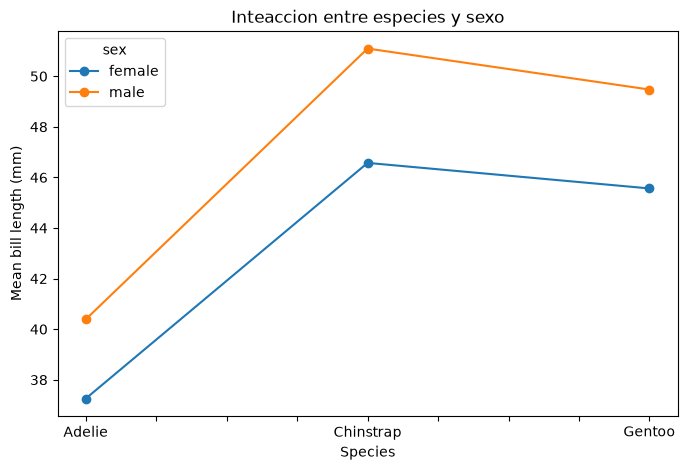

sex,female,male
species,,
Adelie,37.257534,40.390411
Chinstrap,46.573529,51.094118
Gentoo,45.563793,49.473770


In [162]:
mean_table_bill = (
    anova_data_bill
    .groupby(
        ["species", "sex"]
    )["bill_length_mm"]
    .mean()
    .unstack()
)
mean_table_bill.plot(
    marker="o",
    figsize=(8, 5)
)

plt.xlabel("Species")
plt.ylabel(
    "Mean bill length (mm)"
)

plt.title(
    "Inteaccion entre especies y sexo"
)

plt.show()

mean_table_bill

El ANOVA factorial mostró un efecto estadísticamente significativo de la especie sobre la longitud del pico (F=650.479, p<0.001) y un efecto estadísticamente significativo del sexo (F=211.807, p<0.001). Sin embargo, no se encontró una interacción significativa entre especie y sexo (F=2.284, p=0.1035). Por lo tanto, existe evidencia de diferencias asociadas tanto con la especie como con el sexo, pero no existe evidencia suficiente para concluir que el efecto del sexo sobre la longitud del pico cambien entre especies.

### D. Proporciones

Utilizando las variables categóricas del conjunto de datos:



#### 1. Construye un intervalo de confianza del 95 % para la proporción de pingüinos Gentoo.


In [170]:

x = (penguins["species"] == "Gentoo").astype(int)

cl = 0.95
alpha = 1 - cl

# Proporción de la muestra
sample_proportion = np.mean(x)

# Tamaño de la muestra
n = len(x)

# Error estándar 
standard_error = np.sqrt(
    sample_proportion
    * (1 - sample_proportion)
    / n
)

# z value
z_score = stats.norm.ppf(
    1 - alpha/2
)

# Margen de error
margin_of_error = (
    z_score * standard_error
)

# Intervalo de confianza
confidence_interval = (
    sample_proportion - margin_of_error,
    sample_proportion + margin_of_error
)

print("Sample size =", n)
print("Numero en Gentoo =", np.sum(x))
print("Proporción =", sample_proportion)
print("Error estándar =", standard_error)
print("Intervalo de confianza 95% =", confidence_interval)

Sample size = 344
Numero en Gentoo = 124
Proporción = 0.36046511627906974
Error estándar = 0.02588716662755636
Intervalo de confianza 95% = (np.float64(0.30972720202727205), np.float64(0.41120303053086743))


La proporción muestral de pingUinos Gentoo fue de 0.3605, equivalente al 36.05% de la muestra. Con un nivel de confianza del 95%, se estima que la proporción poblacional de pingüinos Gentoo se encuentra entre 30.97% y 41.12%.

#### 2. Construye un intervalo de confianza del 95 % para la proporción de machos.


In [172]:

sex_data = penguins["sex"].dropna()

x = (sex_data == "male").astype(int)

cl = 0.95
alpha = 1 - cl

sample_proportion = np.mean(x)
n = len(x)

standard_error = np.sqrt(
    sample_proportion
    * (1 - sample_proportion)
    / n
)

z_score = stats.norm.ppf(
    1 - alpha/2
)

margin_of_error = (
    z_score * standard_error
)

confidence_interval = (
    sample_proportion - margin_of_error,
    sample_proportion + margin_of_error
)

print("Tamaño de la muestra =", n)
print("úmero de machos =", np.sum(x))
print("Proporción de la muestra =", sample_proportion)
print("Intervalo de confianza 95% =", confidence_interval)

Tamaño de la muestra = 333
úmero de machos = 168
Proporción de la muestra = 0.5045045045045045
Intervalo de confianza 95% = (np.float64(0.4508040014949196), np.float64(0.5582050075140893))


Entre los 333 pingüinos con información disponible sobre sexo, la proporción muestral de machos fue de 0.5045, equivalente al 50.45%. Con un nivel de confianza del 95%, se estima que la proporción poblacional de machos se encuentra entre 45.08% y 55.82%.

#### 3. * Construye un intervalo de confianza para la diferencia entre la proporción de machos en las especies Adelie y Gentoo.


In [174]:
# Adelie - Gentoo

adelie_sex = penguins.loc[
    penguins["species"] == "Adelie",
    "sex"
].dropna()

gentoo_sex = penguins.loc[
    penguins["species"] == "Gentoo",
    "sex"
].dropna()

# variables binarias para m y h
adelie_male = (
    adelie_sex == "male"
).astype(int)

gentoo_male = (
    gentoo_sex == "male"
).astype(int)

cl = 0.95
alpha = 1 - cl

# Muestra de proporciones
p1 = np.mean(adelie_male)
p2 = np.mean(gentoo_male)

n1 = len(adelie_male)
n2 = len(gentoo_male)

# Error estándar de la diferencia de proporciones
standard_error_diff = np.sqrt(
    p1 * (1 - p1) / n1
    +
    p2 * (1 - p2) / n2
)

# z score
z_score = stats.norm.ppf(
    1 - alpha/2
)

# Margen de error
margin_of_error = (
    z_score * standard_error_diff
)

difference = p1 - p2

# Intervalo de confianza
confidence_interval = (
    difference - margin_of_error,
    difference + margin_of_error
)

print("Adelie n =", n1)
print("Gentoo n =", n2)

print("Adelie machos =", np.sum(adelie_male))
print("Gentoo machos =", np.sum(gentoo_male))

print("Proporción de machos Adelie =", p1)
print("Proporción de machos Gentoo =", p2)

print(
    "Diferencia Adelie - Gentoo =",
    difference
)

print(
    "95% Intervalo de confianza =",
    confidence_interval
)

Adelie n = 146
Gentoo n = 119
Adelie machos = 73
Gentoo machos = 61
Proporción de machos Adelie = 0.5
Proporción de machos Gentoo = 0.5126050420168067
Diferencia Adelie - Gentoo = -0.012605042016806678
95% Intervalo de confianza = (np.float64(-0.13361331870099435), np.float64(0.10840323466738101))


La proporción de machos fue de 50.00% en Adelie y 51.26% en Gentoo, con una diferencia estimada Adelie − Gentoo de −1.26 puntos porcentuales. Con un nivel de confianza del 95%, la diferencia poblacional se encuentra entre −13.36 y 10.84 puntos porcentuales. Como el intervalo contiene el valor 0, no existe evidencia suficiente de una diferencia en la proporción de machos entre Adelie y Gentoo.

#### 4. * Determina si existe evidencia suficiente para concluir que más del 30 % de los pingüinos pertenecen a la especie Gentoo.


In [175]:

x = (penguins["species"] == "Gentoo").astype(int)

p0 = 0.30
alpha = 0.05

# Muestra de proporciones
n = len(x)
successes = np.sum(x)
p_hat = successes / n

# Error estándar baho h0
se = np.sqrt(
    p0 * (1 - p0) / n
)

# z estadístico
z_stat = (
    p_hat - p0
) / se

# p value para una prueba de cola derecha
p_value = stats.norm.sf(z_stat)

# Valor crítico 
z_critical = stats.norm.ppf(
    1 - alpha
)

print("n =", n)
print("úmero de Gentoo =", successes)
print("Proporción de la muestra =", p_hat)
print("Error estándar =", se)
print("z estadístico =", z_stat)
print("Valor crítico =", z_critical)
print("p-value =", p_value)

if p_value < alpha:
    print("Rechazamos H0")
else:
    print("No rechazamos H0")

n = 344
úmero de Gentoo = 124
Proporción de la muestra = 0.36046511627906974
Error estándar = 0.024707592280088113
z estadístico = 2.4472281877420605
Valor crítico = 1.6448536269514722
p-value = 0.007197983211268201
Rechazamos H0


Se rechaza la hipótesis nula a un nivel de significancia de 0.05 (z=2.447, p=0.0072). Existe evidencia significativa para concluir que más del 30% de los pinguinos pertenecen a la especie Gentoo, siendo que en  la muestra, la proporción observada fue de 36.05%.

#### 5.Evalúa si la proporción de machos es la misma en Adelie y Gentoo.

In [177]:

adelie_sex = penguins.loc[
    penguins["species"] == "Adelie",
    "sex"
].dropna()

gentoo_sex = penguins.loc[
    penguins["species"] == "Gentoo",
    "sex"
].dropna()

adelie_male = (
    adelie_sex == "male"
).astype(int)

gentoo_male = (
    gentoo_sex == "male"
).astype(int)

alpha = 0.05

# Tamaños de muestra
n1 = len(adelie_male)
n2 = len(gentoo_male)

# Casos de éxito (machosos)
x1 = np.sum(adelie_male)
x2 = np.sum(gentoo_male)

# Proporciones de muestra
p1_hat = x1 / n1
p2_hat = x2 / n2

# Proporción agrupada bajo H0
p_pool = (
    x1 + x2
) / (
    n1 + n2
)

# Error estándar
se = np.sqrt(
    p_pool
    * (1 - p_pool)
    * (1/n1 + 1/n2)
)

# z estadístico
z_stat = (
    p1_hat - p2_hat
) / se

# P-value para una prueba de dos colas
p_value = 2 * stats.norm.sf(
    abs(z_stat)
)

# valor crítico
z_critical = stats.norm.ppf(
    1 - alpha/2
)

print("Adelie n =", n1)
print("Gentoo n =", n2)

print("Adelie machos =", x1)
print("Gentoo machos =", x2)

print(
    "Proporción de machos Adelie =",
    p1_hat
)

print(
    "Proporción de machos Gentoo =",
    p2_hat
)

print(
    "Proporción agrupada =",
    p_pool
)

print("Error estándar =", se)
print("z estadístico =", z_stat)
print("Valor crítico =", z_critical)
print("p-value =", p_value)

if p_value < alpha:
    print("Rechazamos H0")
else:
    print("No rechazamos H0")

Adelie n = 146
Gentoo n = 119
Adelie machos = 73
Gentoo machos = 61
Proporción de machos Adelie = 0.5
Proporción de machos Gentoo = 0.5126050420168067
Proporción agrupada = 0.5056603773584906
Error estándar = 0.061746906071966416
z estadístico = -0.20414046336370958
Valor crítico = 1.959963984540054
p-value = 0.8382437348653554
No rechazamos H0


No se rechaza la hipótesis nula a un nivel de significancia de 0.05 (z=-0.204, p=0.8382). No existe evidencia estadísticamente significativa para concluir que la proporción de machos sea diferente entre Adelie y Gentoo.

### E. Relaciones entre variables

Analiza la relación entre las características físicas de los pingüinos:



#### 1. * Estima la correlación entre masa corporal y longitud de la aleta.


In [179]:
# Elimamos los valores nulos para body_mass_g y flipper_length_mm
data_corr1 = penguins[
    ["body_mass_g", "flipper_length_mm"]
].dropna()

x = data_corr1["flipper_length_mm"]
y = data_corr1["body_mass_g"]

print("n =", len(data_corr1))

n = 342


In [180]:
# Coeficiente de correlación de Pearson
r, p_value = stats.pearsonr(x, y)

print("Correlación de Pearson =", r)
print("p-value =", p_value)

Correlación de Pearson = 0.8712017673060112
p-value = 4.3706809630004724e-107


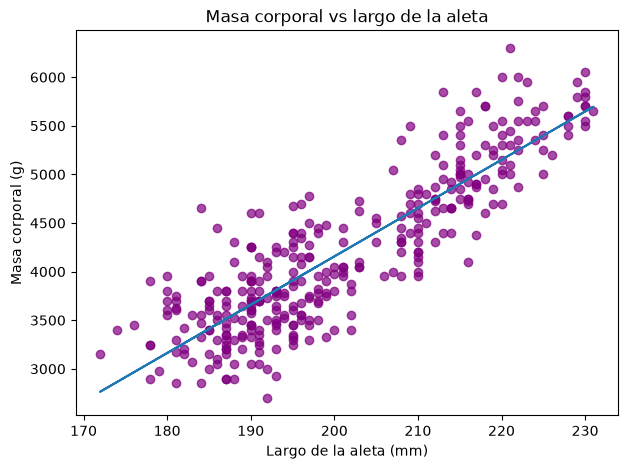

In [213]:
data_corr1 = penguins[
    ["body_mass_g", "flipper_length_mm"]
].dropna()

x = data_corr1["flipper_length_mm"]
y = data_corr1["body_mass_g"]

plt.figure(figsize=(7, 5))

plt.scatter(x, y, alpha=0.7, color="purple")

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

plt.xlabel("Largo de la aleta (mm)")
plt.ylabel("Masa corporal (g)")
plt.title("Masa corporal vs largo de la aleta")

plt.show()

El diagrama de dispersión muestra una relación positiva y aproximadamente lineal entre la longitud de la aleta y la masa corporal. Esta observación concuerda con el coeficiente de Pearson obtenido (r=0.8712), que indica una asociación lineal positiva fuerte. Aunque existen algunas observaciones alejadas de la tendencia y se aprecian agrupamientos posiblemente asociados a las distintas especies, el patrón lineal general es claro.

#### 2. * Prueba si existe una correlación lineal significativa entre ambas variables.


In [186]:

alpha = 0.05

n = len(data_corr1)

r, p_value = stats.pearsonr(x, y)

t_stat = (
    r
    * np.sqrt(
        (n - 2) /
        (1 - r**2)
    )
)

df = n - 2

t_critical = stats.t.ppf(
    1 - alpha/2,
    df
)

print("n =", n)
print("Pearson r =", r)
print("estadistico t  =", t_stat)
print("Grados de libertad =", df)
print("Value crítico =", t_critical)
print("p-value =", p_value)

if p_value < alpha:
    print("Rechazamos H0")
else:
    print("No rechazamos H0")

n = 342
Pearson r = 0.8712017673060112
estadistico t  = 32.722233912337366
Grados de libertad = 340
Value crítico = 1.9669657340892857
p-value = 4.3706809630004724e-107
Rechazamos H0


Se rechaza la hipótesis nula (t=32.722,\ p<0.001). Existe evidencia  significativa de una correlación lineal entre la masa corporal y la longitud de la aleta. La correlación es positiva y fuerte (r=0.8712).

#### 3.* Realiza un análisis similar entre longitud del pico y masa corporal.


In [187]:
# Preparamos los datos 


data_corr2 = penguins[
    ["bill_length_mm", "body_mass_g"]
].dropna()

x = data_corr2["bill_length_mm"]
y = data_corr2["body_mass_g"]

print("n =", len(data_corr2))

n = 342


In [188]:
r, p_value = stats.pearsonr(x, y)

print("Correlación de Pearson =", r)
print("p-value =", p_value)

Correlación de Pearson = 0.5951098244376299
p-value = 3.808282842018042e-34


In [189]:
alpha = 0.05

n = len(data_corr2)

r, p_value = stats.pearsonr(x, y)

t_stat = (
    r
    * np.sqrt(
        (n - 2) /
        (1 - r**2)
    )
)

df = n - 2

t_critical = stats.t.ppf(
    1 - alpha/2,
    df
)

print("n =", n)
print("Pearson r =", r)
print("t statistic =", t_stat)
print("Grados de libertad =", df)
print("Value crítico =", t_critical)
print("p-value =", p_value)

if p_value < alpha:
    print("Rechazamos H0")
else:
    print("No rechazamos H0")

n = 342
Pearson r = 0.5951098244376299
t statistic = 13.654401346388553
Grados de libertad = 340
Value crítico = 1.9669657340892857
p-value = 3.808282842018042e-34
Rechazamos H0


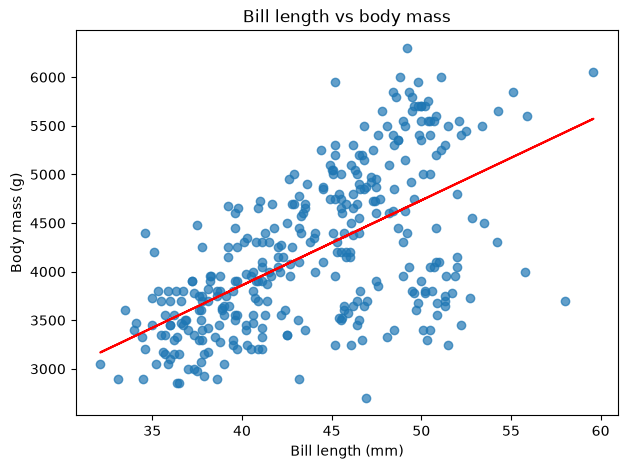

In [192]:
plt.figure(figsize=(7, 5))

plt.scatter(
    x,
    y,
    alpha=0.7
)

m, b = np.polyfit(x, y, 1)

plt.plot(
    x,
    m*x + b,

    color="red"
)

plt.xlabel("Bill length (mm)")
plt.ylabel("Body mass (g)")
plt.title("Bill length vs body mass")

plt.show()

El coeficiente de correlación de Pearson entre la longitud del pico y la masa corporal fue de (r=0.5951), lo que indica una relación lineal positiva de magnitud moderada. La prueba de significancia mostró que esta correlación es estadísticamente significativa (t=13.654, p<0.001), esto tambien esta soportado por la asociacion lineal entre la longitud de la aleta y la masa corporal. Por lo tanto, los pinguinos con picos más largos tienden a presentar una mayor masa corporal.

#### 4. * Determina si existe asociación entre la especie y la isla donde fue observado el pingüino.


In [194]:
# Construye una tabla de contingencia para las variables especie e isla.
contingency_species_island = pd.crosstab(
    penguins["species"],
    penguins["island"]
)

contingency_species_island

island,Biscoe,Dream,Torgersen
species,,,
Adelie,44,56,52
Chinstrap,0,68,0
Gentoo,124,0,0


In [197]:
chi2_stat, p_value, df, expected = stats.chi2_contingency(
    contingency_species_island
)

print("Chi-cuadrado =", chi2_stat)
print("Grados de libertad =", df)
print("p-value =", p_value)

Chi-cuadrado = 299.55032743148195
Grados de libertad = 4
p-value = 1.3545738297192517e-63


In [199]:
expected_df = pd.DataFrame(
    expected,
    index=contingency_species_island.index,
    columns=contingency_species_island.columns
)

expected_df


island,Biscoe,Dream,Torgersen
species,,,
Adelie,74.232558,54.790698,22.976744
Chinstrap,33.209302,24.511628,10.279070
Gentoo,60.558140,44.697674,18.744186


In [200]:

alpha = 0.05

if p_value < alpha:
    print("Rechazamos H0")
else:
    print("No rechazamos H0")

Rechazamos H0


Se rechaza la hipótesis nula de independencia (chi^2=299.550, df=4,p<0.001). Existe evidencia estadísticamente significativa de una asociación entre la especie del pinguino y la isla donde fue observado. POdemos observar que todos los pinguinos Chinstrap de la muestra fueron observados en Dream, todos los Gentoo fueron observados en Biscoe, mientras que Adelie aparece en las tres islas.

#### 5.  Determina si existe asociación entre especie y sexo.


In [201]:
# Limpiamos datos

data_species_sex = penguins[
    ["species", "sex"]
].dropna()

contingency_species_sex = pd.crosstab(
    data_species_sex["species"],
    data_species_sex["sex"]
)

contingency_species_sex

sex,female,male
species,,
Adelie,73,73
Chinstrap,34,34
Gentoo,58,61


In [204]:
chi2_stat, p_value, df, expected = stats.chi2_contingency(
    contingency_species_sex
)

print("Chi-cuadrado =", chi2_stat)
print("Grados de libertad =", df)
print("p-value =", p_value)

Chi-cuadrado = 0.04860717014078318
Grados de libertad = 2
p-value = 0.9759893689765846


In [207]:
expected_df = pd.DataFrame(
    expected,
    index=contingency_species_sex.index,
    columns=contingency_species_sex.columns
)

expected_df



sex,female,male
species,,
Adelie,72.342342,73.657658
Chinstrap,33.693694,34.306306
Gentoo,58.963964,60.036036


In [209]:
alpha = 0.05

if p_value < alpha:
    print("Rechazamos H0")
else:
    print("No rechazamos H0")

No rechazamos H0


In [ ]:
# Proporciones de machos y hembras por especie
pd.crosstab(
    data_species_sex["species"],
    data_species_sex["sex"],
    normalize="index"
)

sex,female,male
species,,
Adelie,0.500000,0.500000
Chinstrap,0.500000,0.500000
Gentoo,0.487395,0.512605


No se rechaza la hipótesis nula de independencia (chi^2=0.0486,df=2,\ p=0.9760). No existe evidencia estadísticamente significativa de una asociación entre la especie y el sexo de los pingüinos.



## Ejercicio 2

Considere las siguientes distribuciones, todas con media poblacional ($\mu = 10$):

* $X_1 \sim N(10, 2^2)$
* $X_2 \sim Exp(0.1)$
* Log-normal con parámetros $\mu_{\text{log}} = \ln(10) - \frac{1}{2}$ y $\sigma_{\text{log}} = 1$.

Para cada distribución, considere tamaños de muestra $n = 5$, $n = 30$ y $n = 100$.

In [215]:
mu = 10
tamanos = [5, 30, 100]
distribuciones = ["Normal", "Exponencial", "Lognormal"]
rng = np.random.default_rng(42)  # Para obtener resultados reproducibles

def generar_muestras(distribucion, n, repeticiones):
    forma = (repeticiones, n)
    
    if distribucion == "Normal":
        return rng.normal(loc=10, scale=2, size=forma)
    
    if distribucion == "Exponencial":
        return rng.exponential(scale=10, size=forma)
    
    if distribucion == "Lognormal":
        mu_log = np.log(10) - 0.5
        return rng.lognormal(mean=mu_log, sigma=1, size=forma)

In [216]:
# Funcion para calcular intervalos de confianza
def calcular_intervalos(muestras):
    n = muestras.shape[1]
    medias = muestras.mean(axis=1)
    desviaciones = muestras.std(axis=1, ddof=1)
    
    t_critico = stats.t.ppf(0.975, df=n - 1)
    margen = t_critico * desviaciones / np.sqrt(n)
    
    limites_inferiores = medias - margen
    limites_superiores = medias + margen
    contienen_mu = (limites_inferiores <= mu) & (mu <= limites_superiores)
    
    return medias, limites_inferiores, limites_superiores, contienen_mu

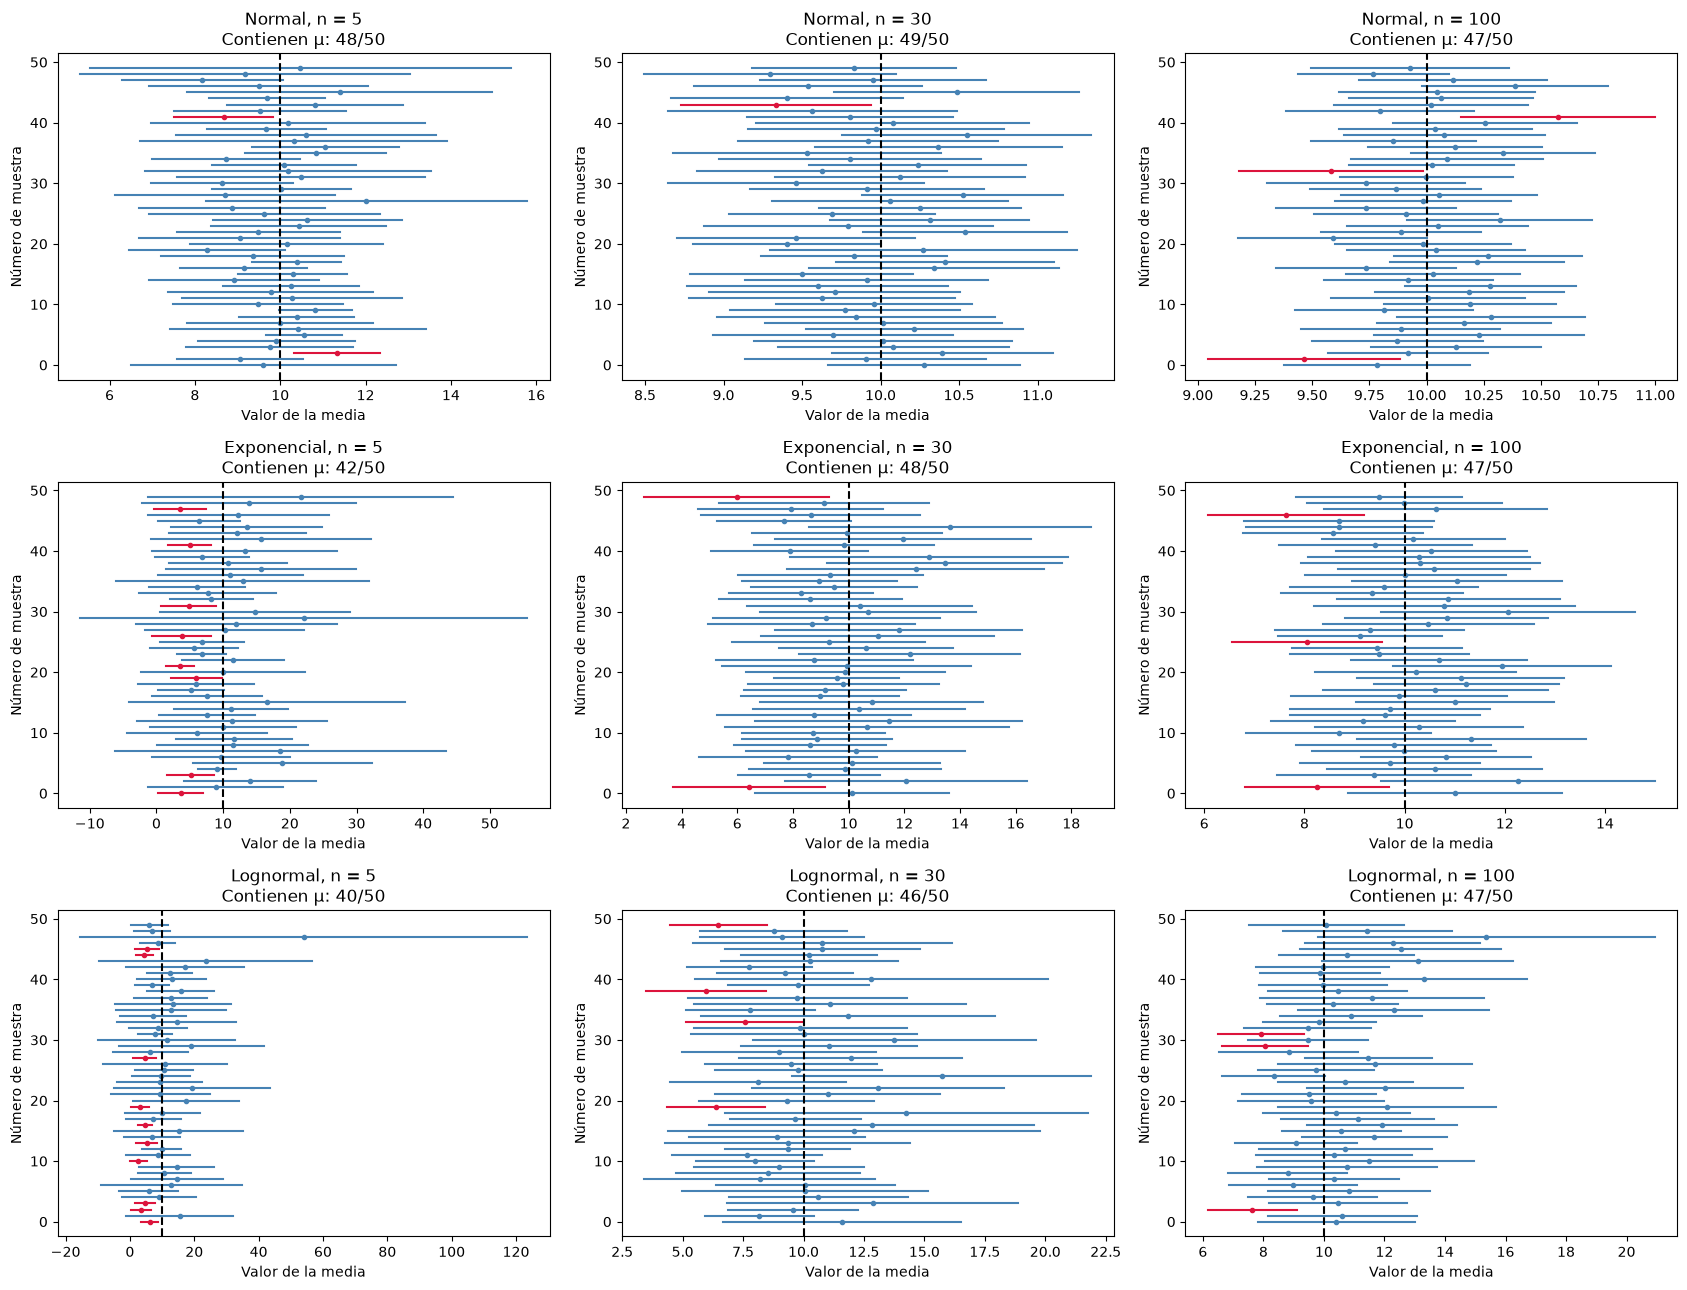

In [217]:
# Generar y graficar los 50 intervalos

fig, ejes = plt.subplots(3, 3, figsize=(17, 13))

for fila, distribucion in enumerate(distribuciones):
    for columna, n in enumerate(tamanos):
        muestras = generar_muestras(distribucion, n, 50)
        medias, inferiores, superiores, contienen = calcular_intervalos(muestras)
        
        ax = ejes[fila, columna]
        
        for i in range(50):
            color = "steelblue" if contienen[i] else "crimson"
            ax.plot([inferiores[i], superiores[i]], [i, i], color=color)
            ax.plot(medias[i], i, "o", color=color, markersize=3)
        
        ax.axvline(mu, color="black", linestyle="--", label="μ = 10")
        ax.set_title(f"{distribucion}, n = {n}\n"
                     f"Contienen μ: {contienen.sum()}/50")
        ax.set_xlabel("Valor de la media")
        ax.set_ylabel("Número de muestra")

plt.tight_layout()
plt.show()

#### Repetir con 5000 muestras

In [218]:
resultados = []
medias_guardadas = {}

for distribucion in distribuciones:
    for n in tamanos:
        muestras = generar_muestras(distribucion, n, 5000)
        medias, inferiores, superiores, contienen = calcular_intervalos(muestras)
        
        medias_guardadas[(distribucion, n)] = medias
        
        resultados.append({
            "Distribución": distribucion,
            "n": n,
            "Cobertura": contienen.mean(),
            "Diferencia respecto a 0.95": contienen.mean() - 0.95,
            "Amplitud promedio": np.mean(superiores - inferiores)
        })

tabla_resultados = pd.DataFrame(resultados)
print(tabla_resultados.to_string(index=False))

Distribución   n  Cobertura  Diferencia respecto a 0.95  Amplitud promedio
      Normal   5     0.9522                      0.0022           4.679579
      Normal  30     0.9504                      0.0004           1.485929
      Normal 100     0.9542                      0.0042           0.791415
 Exponencial   5     0.8840                     -0.0660          21.597287
 Exponencial  30     0.9380                     -0.0120           7.280106
 Exponencial 100     0.9400                     -0.0100           3.920542
   Lognormal   5     0.8212                     -0.1288          22.841344
   Lognormal  30     0.8836                     -0.0664           8.697654
   Lognormal 100     0.9182                     -0.0318           4.936239


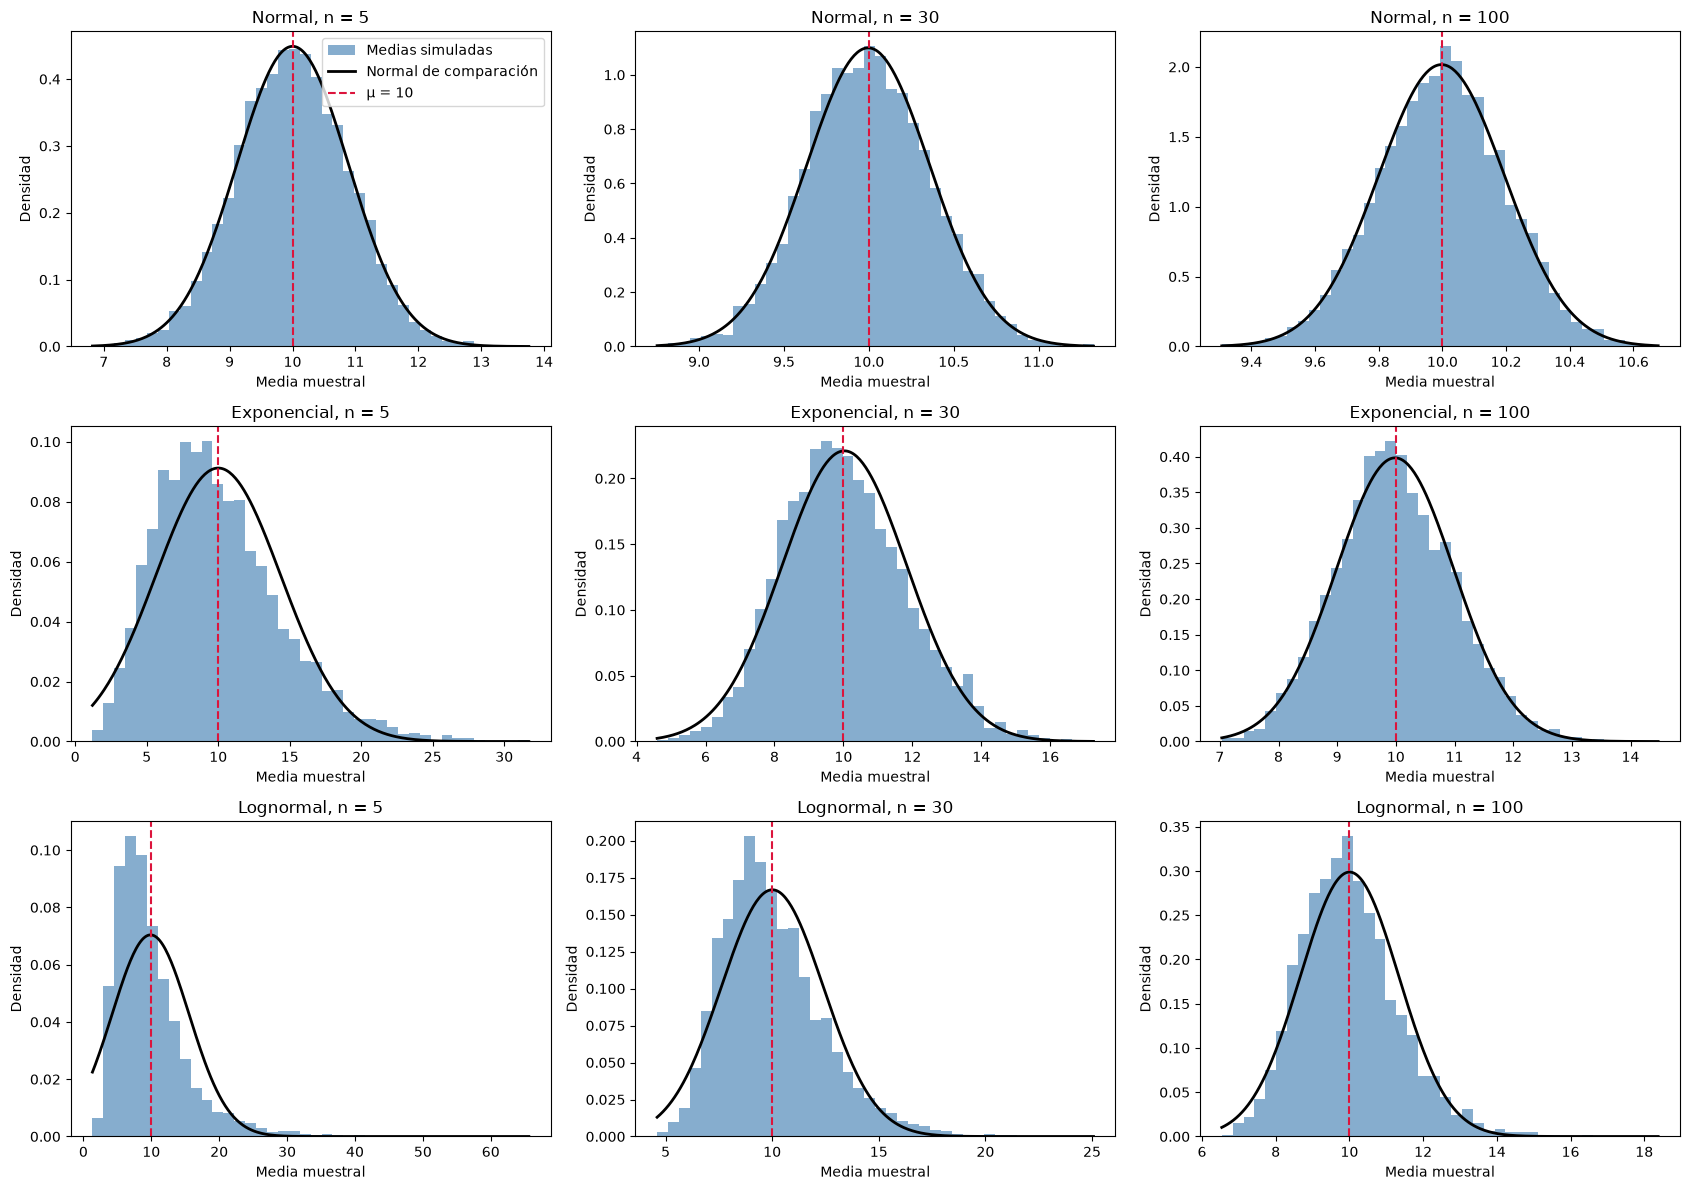

In [219]:
fig, ejes = plt.subplots(3, 3, figsize=(17, 12))

for fila, distribucion in enumerate(distribuciones):
    for columna, n in enumerate(tamanos):
        ax = ejes[fila, columna]
        medias = medias_guardadas[(distribucion, n)]
        
        ax.hist(medias, bins=40, density=True, alpha=0.65,
                color="steelblue", label="Medias simuladas")
        
        x = np.linspace(medias.min(), medias.max(), 300)
        curva_normal = stats.norm.pdf(
            x, loc=medias.mean(), scale=medias.std(ddof=1)
        )
        ax.plot(x, curva_normal, color="black", linewidth=2,
                label="Normal de comparación")
        
        ax.axvline(mu, color="crimson", linestyle="--", label="μ = 10")
        ax.set_title(f"{distribucion}, n = {n}")
        ax.set_xlabel("Media muestral")
        ax.set_ylabel("Densidad")
        
ejes[0, 0].legend()
plt.tight_layout()
plt.show()

#### 4. A partir de los resultados, responda:

a) ¿Cómo cambia la amplitud de los intervalos al aumentar n?

Disminuye en las tres distribuciones. En la normal pasa de 4.68 con n=5 a 0.79 con n=100. Esto ocurre porque al aumentar el tamaño de muestra, la estimación de la media se vuelve más precisa.

b) ¿En qué distribución la aproximación normal funciona mejor con muestras pequeñas?

En la distribución normal. Incluso con n=5, su cobertura fue 0.9522, muy cercana a 0.95.

c) ¿En cuál funciona peor?
En la lognormal. Con n=5, su cobertura fue 0.8212: solo cerca del 82 % de los intervalos incluyeron la media verdadera. Sus histogramas muestran una cola larga hacia la derecha, especialmente con muestras pequeñas.

d) ¿Los resultados sugieren que n=30 siempre es suficiente para garantizar una buena aproximación normal? Justifique.

No. Con n=30, la normal tuvo cobertura 0.9504, pero la exponencial obtuvo 0.9380 y la lognormal solo 0.8836. Aunque las distribuciones de las medias se vuelven más simétricas al aumentar *n*, la rapidez de esa aproximación depende de la distribución original. En particular, la lognormal conserva bastante asimetría con n=30.

## Ejercicio 3

Suponga que se desea probar

$$H_0 : \mu = 100 \quad \text{vs} \quad H_1 : \mu > 100$$

utilizando un nivel de significancia $\alpha = 0.05$. Considere una población normal con desviación estándar $\sigma = 15$.

1. Genere 5000 muestras de tamaño $n = 25$ de una población con $\mu = 100$. Para cada muestra realice la prueba de hipótesis y registre si se rechaza $H_0$. Calcule la proporción de rechazos y compárela con $\alpha = 0.05$. Explique por qué estos rechazos corresponden a errores Tipo I.
2. Repita la simulación utilizando poblaciones con $\mu = 102, \mu = 105 \text{ y } \mu = 110$. Para cada valor de $\mu$, calcule:
   * la proporción de veces que no se rechaza $H_0$, como estimación de $\beta$;
   * la proporción de veces que se rechaza $H_0$, como estimación de la potencia $1 - \beta$.
3. Repita el análisis anterior para tamaños de muestra $n = 10, n = 25, n = 50 \text{ y } n = 100$. Organice los resultados en una tabla y grafique la potencia en función del tamaño de muestra para cada valor de $\mu$.

In [ ]:
# DEfinimos constantes para la simulación 

np.random.seed(123)

mu_0 = 100
sigma = 15
alpha = 0.05
n = 25
num_simulations = 5000

In [221]:
z_critical = stats.norm.ppf(1 - alpha)

print("Valor crítico z =", z_critical)

Valor crítico z = 1.6448536269514722


In [222]:
# Simulamos 5000 muestras
mu_true = 100

rejects = 0

for i in range(num_simulations):

    sample = np.random.normal(
        loc=mu_true,
        scale=sigma,
        size=n
    )

    sample_mean = np.mean(sample)

    z_stat = (
        sample_mean - mu_0
    ) / (
        sigma / np.sqrt(n)
    )

    if z_stat > z_critical:
        rejects += 1

proportion_reject = rejects / num_simulations

print("Número de rechazos =", rejects)
print("Proporción de rechazos =", proportion_reject)
print("Alpha =", alpha)

Número de rechazos = 245
Proporción de rechazos = 0.049
Alpha = 0.05


In [223]:
# Repetir para u=102, 105, 110

mu_values = [102, 105, 110]
n = 25

for mu_true in mu_values:
    rejects = 0
    for i in range(num_simulations):
        sample = np.random.normal(
            loc=mu_true,
            scale=sigma,
            size=n
        )

        sample_mean = np.mean(sample)

        z_stat = (
            sample_mean - mu_0
        ) / (
            sigma / np.sqrt(n)
        )

        if z_stat > z_critical:
            rejects += 1

    power = rejects / num_simulations
    beta = 1 - power

    print("mu =", mu_true)
    print("Beta =", beta)
    print("Power =", power)
    print()

mu = 102
Beta = 0.8318
Power = 0.1682

mu = 105
Beta = 0.49360000000000004
Power = 0.5064

mu = 110
Beta = 0.045399999999999996
Power = 0.9546



In [224]:
# Repetir para n= 10,25,50,100

mu_values = [100, 102, 105, 110]
n_values = [10, 25, 50, 100]

In [225]:
mu_values = [100, 102, 105, 110]
n_values = [10, 25, 50, 100]

results = []

for n in n_values:

    for mu_true in mu_values:
        rejects = 0
        for i in range(num_simulations):

            sample = np.random.normal(
                loc=mu_true,
                scale=sigma,
                size=n
            )

            sample_mean = np.mean(sample)

            z_stat = (
                sample_mean - mu_0
            ) / (
                sigma / np.sqrt(n)
            )

            if z_stat > z_critical:
                rejects += 1

        proportion_reject = (
            rejects / num_simulations
        )

        if mu_true == mu_0:
            beta = np.nan
            power = np.nan
        else:
            power = proportion_reject
            beta = 1 - power

        results.append({
            "n": n,
            "mu": mu_true,
            "Proportion_reject": proportion_reject,
            "Beta": beta,
            "Power": power
        })

results_df = pd.DataFrame(results)

results_df

,n,mu,Proportion_reject,Beta,Power
0,10,100,0.0478,NaN,NaN
1,10,102,0.1086,0.8914,0.1086
2,10,105,0.2700,0.7300,0.2700
3,10,110,0.6792,0.3208,0.6792
4,25,100,0.0444,NaN,NaN
5,25,102,0.1752,0.8248,0.1752
6,25,105,0.5114,0.4886,0.5114
7,25,110,0.9554,0.0446,0.9554
8,50,100,0.0504,NaN,NaN
9,50,102,0.2438,0.7562,0.2438


In [226]:
power_table = results_df.pivot(
    index="n",
    columns="mu",
    values="Proportion_reject"
)

power_table

mu,100,102,105,110
n,,,,
10,0.0478,0.1086,0.2700,0.6792
25,0.0444,0.1752,0.5114,0.9554
50,0.0504,0.2438,0.7660,0.9984
100,0.0514,0.3844,0.9580,1.0000


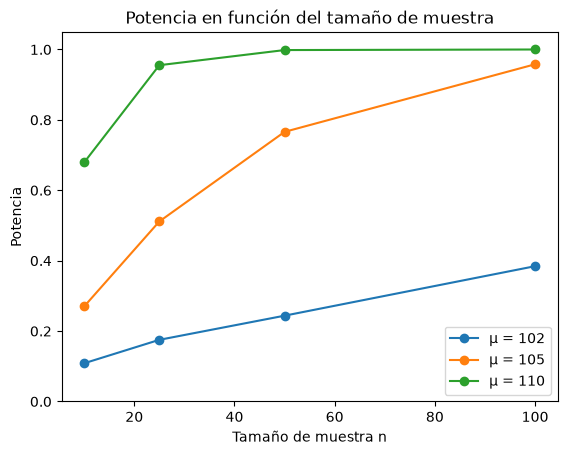

In [227]:
for mu_true in [102, 105, 110]:
    subset = results_df[
        results_df["mu"] == mu_true
    ]

    plt.plot(
        subset["n"],
        subset["Power"],
        marker="o",
        label=f"μ = {mu_true}"
    )

plt.xlabel("Tamaño de muestra n")
plt.ylabel("Potencia")
plt.title("Potencia en función del tamaño de muestra")
plt.legend()
plt.ylim(0, 1.05)

plt.show()

4. A partir de los resultados, responda:
   * Cuando $H_0$ es verdadera, ¿qué relación existe entre la proporción de rechazos y $\alpha$?

Cuando H0 es verdadera la proporción de rechazos estima la probabilidad de error Tipo I y debe ser aproximadamente igual a alpha. En la simulación se obtuvieron valores cercanos a 0.05, como 0.049 en el primer experimento.

   * ¿Qué ocurre con el error Tipo II cuando la verdadera media se aleja de $\mu = 100$?

   Disminuye. A medida que la verdadera media se aleja del valor planteado por H0, resulta más fácil detectar que la H0 es falsa. Por ejemplo, con (n=25). Para mu=110. En mu=102, la potencia fue solamente 0.1682, mientras que para mu=105 aumentó a 0.5064 y para mu=110 alcanzó 0.9546. Simultáneamente, la probabilidad de cometer un error Tipo II disminuyó de 0.8318 a 0.0454.

   * ¿Cómo cambia la potencia al aumentar el tamaño de muestra?

   La potencia aumenta. Un mayor tamaño de muestra reduce el error estándar y permite detectar diferencias reales respecto a mu=100.

   * Para un mismo tamaño de muestra, ¿es más fácil detectar una diferencia pequeña o una diferencia grande?
   
   Para un mismo tamaño de muestra, una diferencia grande respecto al valor planteado por H0 es más fácil de detectar que una diferencia pequeña. Por ello, la potencia es mayor mientras mayor sea el tamaño del efecto. Por ejemplo, con n=10, la potencia fue 0.1086 para mu=102, pero 0.6792 para mu=110.
   
   * ¿Puede una prueba no rechazar $H_0$ aun cuando $H_0$ sea falsa? ¿Qué tipo de error representa?

   Sí una prueba puede no rechazar H0 aunque sea falsa esto corresponde a un error Tipo II.